# Definindo o problema

Temos sequências de 4 tipos de Covid-19 diferentes: Alpha, Delta, Gamma e Omicron. O problema está em classificar qual é o tipo de Covid-19 com base nas sequências genéticas.

### Importando as Bibliotecas Necessárias

In [1]:
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
!pip install torchinfo biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 21.6 MB/s eta 0:00:00


In [3]:
import numpy as np # Permite manipulação de matrizes e vetores
import pandas as pd # Biblioteca para trabalhar com dataframes
import torch # Biblioteca para construir e executar as redes neurais
from sklearn.model_selection import train_test_split # Divir entre dados de treino, teste e validação
from torch.utils.data import DataLoader, TensorDataset
# DataLoader: ferramenta da biblioteca PyTorch que facilita o carregamento de dados em pequenos lotes (batches),
# especialmente útil no treinamento de redes neurais, onde processar tudo de uma vez pode ser pesado para a memória.
# TensorDataset: transforma dados normais (como listas, arrays) em tensores organizados,
# que o PyTorch pode utilizar como conjuntos de dados.

from sklearn.preprocessing import LabelEncoder
# LabelEncoder: faz parte da biblioteca scikit-learn e é usado para converter dados categóricos em números.
# Por exemplo, transforma as classes "Alpha", "Beta", "Delta" em 0, 1 e 2.
# Isso é necessário porque algoritmos de machine learning trabalham com números, não com texto.

import torch.nn as nn
# Aqui estamos importando o módulo 'nn' (neural network) da biblioteca PyTorch.
# Esse módulo contém classes e funções para criar e treinar redes neurais, como camadas (layers) e funções de ativação.

from torchinfo import summary
# summary: exibe um resumo da estrutura da rede neural.
# Mostra quantas camadas há, o tamanho de cada uma, quantos parâmetros estão sendo treinados, entre outras informações úteis.
# É semelhante ao 'model.summary()' do Keras, se você já viu.

from sklearn.metrics import matthews_corrcoef, classification_report
# matthews_corrcoef: métrica estatística que avalia a qualidade da classificação, especialmente útil para dados desbalanceados.
# classification_report: imprime um relatório com métricas como precisão, recall e f1-score para cada classe prevista.

import shap
# SHAP (SHapley Additive exPlanations): biblioteca usada para explicar previsões de modelos de machine learning.
# Ela mostra como cada característica dos dados influenciou a decisão do modelo — utilizado para interpretabilidade.

import matplotlib.pyplot as plt
# matplotlib.pyplot: biblioteca para criação de gráficos e visualizações em Python.
# Muito utilizada para visualizar resultados, curvas de treinamento, etc.

from Bio import SeqIO
# SeqIO: faz parte da biblioteca Biopython.
# É usada para ler e escrever arquivos de sequências biológicas, como os formatos FASTA — muito comum em bioinformática.

from collections import Counter
# Counter: ferramenta da biblioteca padrão do Python para contar quantas vezes cada item aparece em uma lista ou sequência.
# Por exemplo, pode contar quantas vezes cada letra aparece em uma string.

import os
# os: biblioteca padrão do Python que permite interagir com o sistema operacional.
# Pode ser usada para navegar em diretórios, verificar a existência de arquivos, criar pastas, etc.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
pasta = "/content/drive/My Drive/Curso_Xmeeting_2026"
os.chdir(pasta)

print("Diretório atual:", os.getcwd())

Diretório atual: /content/drive/My Drive/Curso_Xmeeting_2026


In [6]:
# Se precisar extrair o zip da pasta
#import zipfile

#for arquivo in os.listdir():
#    if arquivo.endswith(".zip"):
#        caminho_zip = os.path.join(pasta, arquivo)
#        with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
#            zip_ref.extractall(pasta)
#        print(f"Arquivo {arquivo} extraído com sucesso!")

### Preparando os dados para a rede neural

In [7]:
data = pd.read_csv('Data/dataframe.csv')

In [8]:
data.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
data

,AAAAAAC,AAAACCG,AAAACGC,AAAACGG,AAAAGGG,AAAATCG,AAACCGA,AAACCGG,AAACGGT,AAACGTG,...,TTTCGTA,TTTCGTT,TTTCTCG,TTTGACG,TTTGATC,TTTTAGG,TTTTCGA,TTTTCGT,TTTTGCG,CLASS
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Delta
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Delta
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Delta
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Delta
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Delta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Alpha
119996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Alpha
119997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Alpha
119998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VOC_Alpha


In [10]:
"""
  Perceba que os dados da classe estão escritos como VOC_Alpha, VOC_Delta, etc
  Precisamos passar para números, a rede neural não aceita dados não numéricos
"""
label_encoder = LabelEncoder()
data['CLASS'] = label_encoder.fit_transform(data['CLASS'])

In [11]:
data['CLASS'].value_counts()

,count
CLASS,
1,30000
2,30000
3,30000
0,30000


In [12]:
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapeamento das classes:", class_mapping)

Mapeamento das classes: {'VOC_Alpha': np.int64(0), 'VOC_Delta': np.int64(1), 'VOC_Gamma': np.int64(2), 'VOC_Omicron': np.int64(3)}


In [13]:
"""
  Primeiro passo é dividir os dados em treino, teste e validação:
  - treino: Dados que vão de fator fazer o modelo aprender
  - validação: Dados que nos ajuda a identificar o andamento do treinamento e
  para ajudar no ajuste dos hiperparâmetros, utilizamos ele como base para
  identificar possíveis sobreajustes no modelo
  - teste: Após todo o processo de treinamento do modelo podemos verificar
  a acertividade do modelo utilizando os dados separados para o teste.
"""

X_train, X_test, y_train, y_test = train_test_split(
    data.drop('CLASS', axis=1),        # Remove a coluna 'CLASS' dos dados para usar apenas as características (features).
    data['CLASS'],                     # Aqui estamos pegando apenas a coluna 'CLASS', que é o alvo (o que queremos prever).
    stratify=data['CLASS'],            # Garante que a proporção de classes seja mantida na divisão dos dados.
    shuffle=True,                      # Embaralha os dados antes de dividir. Importante para evitar viés na ordem original.
    test_size=0.2,                     # 20% dos dados serão separados para o conjunto de teste.
    random_state=42                    # Define uma "semente" para o gerador aleatório, garantindo que os resultados sejam 'repetidos' identicamente
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,                 # Agora dividimos o conjunto de treinamento original em treino (X_train) e validação (X_val).
    stratify=y_train,                 # Mantém a proporção das classes também na validação.
    test_size=0.2,                    # 20% do conjunto de treino original será usado para validação.
    random_state=42                   # Mesma semente para garantir reprodutibilidade.
)


# Convertendo para tensores PyTorch

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
# Converte os dados de entrada de treino (X_train) para um array NumPy e depois para um tensor do PyTorch.
# dtype=torch.float32: especifica que os valores são números decimais (ponto flutuante 32 bits), exigido pelo modelo.

X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
X_val = torch.tensor(np.array(X_val), dtype=torch.float32)

y_train = torch.tensor(np.array(y_train), dtype=torch.long)
# Converte os rótulos (valores da classe) de treino em tensores de inteiros longos (necessário para classificação no PyTorch).

y_test =  torch.tensor(np.array(y_test), dtype=torch.long)
y_val = torch.tensor(np.array(y_val), dtype=torch.long)

In [14]:
train_dataset = TensorDataset(X_train, y_train)
# Cria um "dataset" (conjunto de dados) para o PyTorch com os dados de treinamento (X_train) e seus respectivos rótulos (y_train).
# TensorDataset basicamente empacota os dados e os rótulos juntos, permitindo que o modelo saiba o que treinar e o que prever.

val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Cria um "carregador de dados" (data loader) para o conjunto de treino.
# Ele divide os dados em pequenos blocos chamados *batches* de 32 exemplos por vez.
# shuffle=True embaralha os dados a cada época de treino, ajudando o modelo a aprender melhor.

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Data loader para o conjunto de validação e Teste.
# Aqui não embaralhamos os dados (shuffle=False), pois a ordem não precisa ser aleatória, já que não estamos treinando com eles.

In [17]:
print(X_train.shape, X_test.shape, X_val.shape)
# Esse comando retorna as "formas" (dimensões) dos tensores X_train, X_test e X_val.
# Em outras palavras, ele mostra quantas amostras (linhas) e quantas características (colunas) existem em cada um desses conjuntos de dados.

"""
Exemplo de saída possível:
(torch.Size([76800, 1516]),
 torch.Size([24000, 1516]),
 torch.Size([19200, 1516]))

Interpretação:
- X_train tem 76800 exemplos, cada um com 1516 características (valores de entrada).
- X_test tem 24000 exemplos.
- X_val tem 19200 exemplos.

Saber o .shape é importante para confirmar se a divisão dos dados foi feita corretamente
e se o formato está compatível com o modelo que será treinado.
"""

torch.Size([76800, 1516]) torch.Size([24000, 1516]) torch.Size([19200, 1516])


## MLP

In [21]:
# 1° passo é definir o modelo
class MLP(nn.Module):
  """
  No init passamos os parâmetros que desejamos para o modelo,
  e dentro da função definimos as camadas que serão utilizadas
  Aqui estamos definindo uma classe chamada MLP, que representa uma rede neural do tipo Perceptron Multicamadas (Multi-Layer Perceptron).
  Essa classe herda (ou seja, utiliza as funcionalidades) da classe nn.Module, que faz parte do PyTorch.
  Toda rede neural no PyTorch deve herdar de nn.Module para funcionar corretamente.
  """

  def __init__(self, input_size, hidden_size, output_size):
    """
    Este é o método construtor da classe. Ele é chamado automaticamente quando criamos uma instância do modelo.

    Parâmetros:
    - input_size: número de características (colunas) de entrada. Depende do seu conjunto de dados.
    - hidden_size: quantidade de neurônios na camada oculta. Você pode escolher esse valor.
    - output_size: número de saídas possíveis. Se você estiver classificando em 4 categorias, esse valor será 4.
    """
    super(MLP, self).__init__()
    # Esta linha é obrigatória. Ela chama o construtor da classe "pai" (nn.Module),
    # garantindo que todas as funcionalidades internas do PyTorch estejam disponíveis.

    self.dense_layer1 = nn.Linear(input_size, hidden_size)
    # Primeira camada densa (totalmente conectada).
    # Ela pega todos os valores de entrada e os conecta a cada neurônio da camada oculta.
    # A operação feita aqui é: saída = entrada × pesos + viés (bias)

    self.relu = nn.ReLU()
    # ReLU é uma função de ativação. Ela é usada logo após a camada densa para introduzir não-linearidade.
    # Ela transforma os valores negativos em zero, e mantém os positivos como estão.
    # Isso ajuda a rede a aprender padrões mais complexos.

    self.dense_layer2 = nn.Linear(hidden_size, output_size)
    # Segunda camada densa, que conecta a camada oculta à camada de saída.
    # Ela reduz os neurônios ocultos para o número de classes que queremos prever (ex: 4 classes = 4 saídas).

    #self.softmax = nn.Softmax(dim=1)
    # Softmax transforma os valores da saída final em probabilidades (valores entre 0 e 1 que somam 1).
    # A dimensão (dim=1) significa que estamos aplicando softmax nas colunas (ou seja, nas classes).
    # Isso é importante para classificação multiclasse.


  """
  Após as definições das camadas no init, na função foward escrevemos como
  a rede deve ser executada e qual a ordem de execução ao chamar o modelo
  """
  def forward(self, x):
    """
    A função forward define a ordem que os dados percorrem pela rede quando ela é executada.

    x: é o dado de entrada (ex: uma linha do conjunto de dados, com várias características).
    """
    x = self.dense_layer1(x)  # Passa os dados pela primeira camada densa
    x = self.relu(x)          # Aplica a função de ativação ReLU
    x = self.dense_layer2(x)  # Passa pela segunda camada densa (camada de saída)
    #x = self.softmax(x)       # Aplica softmax para transformar os valores em probabilidades
    return x                  # Retorna as probabilidades para cada classe prevista

In [22]:
# Após criada a estrutura do modelos, temos que cria-lo para esse problema
input_size = X_train.shape[1]
# Aqui estamos pegando a quantidade de características (ou colunas) de entrada que cada exemplo possui.
# X_train.shape retorna as dimensões do tensor (linhas, colunas), e o índice [1] pega o segundo valor: a quantidade de colunas.
# Isso é importante porque o modelo precisa saber quantos valores ele receberá como entrada para cada amostra.

output_size = len(np.unique(y_train))
# Aqui estamos descobrindo quantas classes diferentes existem nos rótulos de treino (y_train).
# np.unique(y_train) retorna um array com todos os valores únicos encontrados (ex: [0, 1, 2, 3]).
# len(...) conta quantos valores únicos existem — ou seja, o número de classes que o modelo deve prever.
# Isso será usado como o número de neurônios na camada de saída do modelo.

"""
  Caso uitlize placas de vídeo (como é o caso do colab) a velocidade de treino
  é muito maior do que a uitlização do processador. Isso se deve ao fator que
  redes neurais nada mais são do que multiplicadores de grandes matrizes.
  Enquanto a cpu tem poucos núcleos (4-64), a GPU tem milhares, isso permite
  que as multiplicações sejam executadas em paralelo, por serem operações simples.
  Existem outras vantagens, mas a execução em paralelo é a principal.
"""

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Aqui estamos definindo em qual dispositivo o modelo será executado: na GPU (se disponível) ou na CPU.
# "cuda" é o nome usado pelo PyTorch para se referir à GPU (placa de vídeo) da NVIDIA.
# torch.cuda.is_available() verifica se há uma GPU disponível e configurada para uso.
# Se houver GPU, ele usará "cuda"; caso contrário, ele usará "cpu".
# Isso é muito importante para acelerar o treinamento, pois GPUs são muito mais rápidas que CPUs para esse tipo de tarefa.

modelo_mlp_1 = MLP(input_size=input_size, hidden_size=64,
                   output_size=output_size).to(dev)
# Aqui estamos criando uma instância do nosso modelo MLP (a rede neural que definimos anteriormente).
# Parâmetros:
# - input_size: quantidade de entradas (características do dado).
# - hidden_size=64: a camada oculta terá 64 neurônios. Esse valor pode ser ajustado conforme a complexidade do problema.
# - output_size: número de classes a serem previstas.
#
# .to(dev): envia o modelo para o dispositivo escolhido (GPU ou CPU).
# Isso garante que tanto os dados quanto o modelo estejam no mesmo lugar, o que é necessário para que o treinamento funcione corretamente.

In [23]:
"""
 Usando summary do torchinfo é possível visualizar o modelo de forma intuitiva.

 Vamos tentar entender o número de parâmetros
 Na 1° Camada Linear temos um input_size de 1516 e 64 perceptrons o que nos leva
 a 1516 x 64 = 97024 somando 64 bias temos os 97.088.
 Nas camadas de ativação não temos parametros, apenas transformamos os dados
 Na 2° Camada linear temos agora não mais 1516 como input_size e sim a saída da
 última camada que tem 64, com isso temos 64*4 + 4(bias) = 260
"""
summary(modelo_mlp_1, input_size=(1, input_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 4]                    --
├─Linear: 1-1                            [1, 64]                   97,088
├─ReLU: 1-2                              [1, 64]                   --
├─Linear: 1-3                            [1, 4]                    260
Total params: 97,348
Trainable params: 97,348
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 0.39
Estimated Total Size (MB): 0.40

In [24]:
"""
  Construido o modelo precisamos definir quem é o otimizador e qual função de
  perda queremos utilizar.
  Otimizador: Para esse problema podemos começar usando Adam que em geral
  funciona bem (mesmo que AdamW normalmente performe melhor)
  Função de Perda: Como visto anteriormente, esse é um problema de classificação
  com 4 classes diferentes, sendo assim podemos usar perda CrossEntropy
"""
funcao_perda = nn.CrossEntropyLoss()
# Aqui estamos definindo a função de perda (também chamada de "loss function").
# A função de perda mede o quão boa (ou ruim) é a previsão do modelo comparada com a realidade (os rótulos verdadeiros).
# nn.CrossEntropyLoss() é uma função comum para problemas de classificação multiclasse.

otimizador = torch.optim.Adam(modelo_mlp_1.parameters(), lr=0.001,
                              betas=(0.9, 0.999))
# Aqui estamos criando o otimizador que vai ajustar os pesos do modelo durante o treinamento.
# O otimizador escolhe a direção e a intensidade das atualizações dos pesos (ou seja, como o modelo vai aprender com os erros).
# Parâmetros do Adam:
# - modelo_mlp_1.parameters(): passa todos os parâmetros (pesos e bias) do modelo para o otimizador.
# - lr=0.001: taxa de aprendizado (learning rate), que define o tamanho dos passos que o otimizador dá para melhorar o modelo.
#     - Se a taxa for muito alta, o modelo pode "pular" a solução correta. Se for muito baixa, o aprendizado será muito lento.
# - betas=(0.9, 0.999): são valores que controlam o "momento" e o "suavizado" do otimizador. Eles ajudam o otimizador a ser mais estável e eficiente.

In [25]:
"""
  Definido o modelo, a função de perda e o otimizador precisamos agora construir
  a função para o treinamento do modelo.
  A função train_model recebe o número de épocas que desejamos treinar o modelo.
"""

def train_model(model, epochs, train_loader, val_loader, optimizer, loss):
  """
  Função para treinar o modelo. A função recebe o modelo, número de épocas, os carregadores de dados para
  treinamento e validação, o otimizador e a função de perda.
  """
  dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  # Aqui verificamos se há uma GPU disponível. Se sim, o modelo será treinado nela (cuda),
  # se não, ele será treinado na CPU (processador normal do computador).

  model.train()  # 'Ativa' o modelo para o aprendizado, indicando que estamos no modo de treinamento.

  for epoch in range(epochs):
    # Um loop para rodar o treinamento por um número definido de épocas (épocas são iterações completas sobre os dados).
    for X_batch, y_batch in train_loader:
      # Train_loader fornece um lote de dados (X_batch com entradas e y_batch com rótulos) para treinamento.
      # Aqui, estamos pegando os dados do lote (batch).
      X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
      # Envia os dados de entrada (X_batch) e os rótulos (y_batch) para o dispositivo correto (GPU ou CPU).

      optimizer.zero_grad()
      # O PyTorch acumula os gradientes durante o treinamento, e a cada iteração precisamos "zerar" os gradientes
      # para que a atualização dos pesos seja feita corretamente.

      outputs = model(X_batch)  # Passamos os dados de entrada (X_batch) para o modelo, e obtemos as previsões (outputs).
      perda = loss(outputs, y_batch)  # Calculamos a perda entre as previsões do modelo e os rótulos reais (y_batch).
      perda.backward()  # Realiza o "backpropagation", ou retropropagação, que calcula os gradientes.
      optimizer.step()  # O otimizador usa os gradientes calculados para ajustar os pesos do modelo.

    """
    Podemos parar aqui, mas quero analisar o desempenho nos dados de validação
    a cada epoca. Com isso podemos analsiar mais de perto quando o modelo começa
    a ter overfiting (caso ocorra) e com esses resultados é possível escolher
    um número de epocas melhor. Como métrica vou utilizar apenas acurácia geral
    do modelo. (No teste podemos utilizar metricas mais avançadas)
    """
    model.eval() # Mudamos o modelo para o modo de "avaliação", indicando que não estamos mais treinando.
    correct, total = 0, 0
    # Inicializamos variáveis para contar as previsões corretas e o total de amostras.

    # Como não estamos treinando, não precisamos calcular gradiente
    with torch.no_grad():
      for X_val_batch, y_val_batch in val_loader:
        # Pegamos os dados de validação em lotes do val_loader.
        X_val_batch, y_val_batch = X_val_batch.to(dev), y_val_batch.to(dev)
        # Enviamos os dados de validação para o dispositivo correto (GPU ou CPU).
        val_outputs = model(X_val_batch)
        # Fazemos as previsões com o modelo para os dados de validação.

        _, predicted = torch.max(val_outputs, 1)
        # torch.max pega o valor máximo de cada vetor de saída (para escolher a classe com maior probabilidade).
        # O valor 1 indica que estamos pegando o índice do valor máximo ao longo das colunas (classes).

        total += y_val_batch.size(0)  # Conta o total de amostras no lote de validação.

        correct += (predicted == y_val_batch).sum().item()
        # Conta quantas previsões estavam corretas comparando as classes previstas com as reais (y_val_batch).
      val_accuracy = correct / total # Calcula a acurácia (precisão) de validação, dividindo o número de acertos pelo total.

    print(f"Treino: epoca:{epoch+1}/{epochs}, Loss: {perda.item():.4f}, Val Accuracy: {val_accuracy:.4f}")
    # Exibe os resultados da época: a perda do modelo (quanto ele errou) e a acurácia no conjunto de validação.

    model.train() # Voltamos o modelo para o modo de "treinamento" após a validação.

In [27]:
train_model(model = modelo_mlp_1, epochs = 3, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)
# Este código chama a função train_model que definimos anteriormente.
# Ele está passando os seguintes parâmetros para a função de treinamento:

# - modelo_mlp_1: Este é o modelo que queremos treinar, o qual foi definido anteriormente como uma rede neural (MLP).
# - 1: O número de épocas. Aqui estamos configurando o treinamento para rodar por apenas 1 época.
#     - Uma época significa que o modelo verá todos os dados de treinamento uma vez.
#     - Se você quiser treinar por mais épocas, basta aumentar esse número (ex: 10, 50, etc.).
# - train_loader=train_loader: O carregador de dados de treinamento. Ele fornece os lotes (batches) de dados de treino para o modelo.
# - val_loader=val_loader: O carregador de dados de validação. Ele fornece os lotes de dados usados para avaliar o desempenho do modelo a cada época.
# - optimizer=otimizador: O otimizador usado para ajustar os pesos do modelo durante o treinamento.
# - loss=funcao_perda: A função de perda usada para medir o erro do modelo.

Treino: epoca:1/3, Loss: 0.0000, Val Accuracy: 1.0000
Treino: epoca:2/3, Loss: 0.0000, Val Accuracy: 1.0000
Treino: epoca:3/3, Loss: 0.0000, Val Accuracy: 1.0000


In [28]:
def evaluate_model(model, train_loader, test_loader):
  """
  Função para avaliar o desempenho do modelo no conjunto de treinamento e no conjunto de teste.
  Ela calcula métricas como precisão, recall, F1-score e a correlação de Matthews.
  """
  dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  # Verifica se há uma GPU disponível. Se houver, usa a GPU ("cuda"), caso contrário, usa a CPU.
  # Essa linha é importante para garantir que o modelo seja avaliado no dispositivo correto (GPU ou CPU).
  def get_metrics(loader, model, dev, dados="Treino"):
    """
    Função interna para calcular as métricas de avaliação, como a precisão e a correlação de Matthews.
    """
    model.eval()  # Define o modelo para o modo de avaliação. Isso desativa comportamentos como dropout.
    true_labels = []  # Lista para armazenar os rótulos reais (verdadeiros).
    predicted_labels = []  # Lista para armazenar os rótulos previstos pelo modelo.
    with torch.no_grad(): # Durante a avaliação, não precisamos calcular gradientes.
    # A função 'torch.no_grad()' desativa o cálculo de gradientes para economizar memória.
      for X_batch, y_batch in loader:
        # Itera sobre o carregador de dados (train_loader ou test_loader), pegando os lotes de dados e rótulos.
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        # Envia os dados de entrada (X_batch) e os rótulos (y_batch) para o dispositivo correto (GPU ou CPU).
        outputs = model(X_batch) # Passa os dados de entrada pelo modelo para obter as previsões.
        _, predicted = torch.max(outputs, 1)
        # torch.max é usado para pegar a classe com a maior probabilidade para cada amostra no lote.
        # Ele retorna o valor máximo e o índice (a classe prevista).
        true_labels.extend(y_batch.cpu().numpy())  # Adiciona os rótulos reais (verdadeiros) à lista.
        predicted_labels.extend(predicted.cpu().numpy())  # Adiciona as previsões à lista.

      true_labels = np.array(true_labels) # Converte a lista para um array NumPy.
      predicted_labels = np.array(predicted_labels) # Converte a lista para um array NumPy.

      print("------------------------------------------------------------------")
      print(f"Resultados obtidos no {dados}:")
      print(classification_report(true_labels, predicted_labels))
      print(f"Correlação de Mattews: ", matthews_corrcoef(true_labels, predicted_labels))

  get_metrics(train_loader, model, dev)
  get_metrics(test_loader, model, dev, dados="Teste")
  # Calcula as métricas para o conjunto de treinamento (train_loader) e o conjunto de teste (test_loader).

In [29]:
evaluate_model(modelo_mlp_1, train_loader=train_loader, test_loader=test_loader)

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19200
           1       1.00      1.00      1.00     19200
           2       1.00      1.00      1.00     19200
           3       1.00      1.00      1.00     19200

    accuracy                           1.00     76800
   macro avg       1.00      1.00      1.00     76800
weighted avg       1.00      1.00      1.00     76800

Correlação de Mattews:  1.0
------------------------------------------------------------------
Resultados obtidos no Teste:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       1.00      1.00      1.00      6000
           2       1.00      1.00      1.00      6000
           3       1.00      1.00      1.00      6000

    accuracy                           1.00     24000
   macro avg      

Perceba que o problema foi super simples de ser solucionado. Isso se deve a execelentes features, que ocorreu por causa de comparmors as sequências genéticas a uma sequência de referência que foi o caso 0.

Agora pense no caso que não temos nenhuma sequência de referência e queremos criar um modelo para prever a classe como poderiamos fazer ? Vamos continuar usando MLP, mas agora precisamos extrair features.

Algumas opções seriam:
- Kmers
- Orfs
- Tipos de Orfs
- Tamanho das sequências

Para esse problema vou usar apenas Kmers como feature.

In [31]:
pasta = "/content/drive/My Drive/Curso_Xmeeting_2026/Data"
os.chdir(pasta)
print("Diretório atual:", os.getcwd())

Diretório atual: /content/drive/My Drive/Curso_Xmeeting_2026/Data


In [32]:
def get_kmers(sequence, k=4):
    """
    Função para extrair todos os k-mers de uma sequência de nucleotídeos.
    Um k-mer é uma subsequência contínua de comprimento k.
    """
    # Retorna uma lista com todos os k-mers da sequência dada.
    # A compreensão de lista cria todas as subsequências possíveis de comprimento k.
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
    # Exemplo: Se k=4 e a sequência for 'ATCGTA', os k-mers serão: ['ATCG', 'TCGT', 'CGTA']

def count_kmers(sequence, k=4):
    """
    Função para contar as ocorrências de cada k-mer em uma sequência de nucleotídeos.
    """
    # Chama a função get_kmers para obter todos os k-mers da sequência
    kmers = get_kmers(sequence, k)
    # Usando o Counter para contar a ocorrência de cada k-mer na lista gerada
    return dict(Counter(kmers))
    # Retorna um dicionário, onde as chaves são os k-mers e os valores são suas contagens.

def process_fasta_files(fasta_files, k=4):
    """
    Função para processar múltiplos arquivos FASTA, extrair os k-mers e suas contagens,
    e retornar um único dataframe com todos os dados.
    """
    dataframes = []  # Lista para armazenar os dataframes de cada arquivo
    for fasta_file in fasta_files:
        # Obtém o nome da classe baseado no nome do arquivo FASTA (usando a parte antes da extensão)
        class_name = os.path.splitext(os.path.basename(fasta_file))[0]
        data = []  # Lista para armazenar os dados de cada sequência no arquivo FASTA
        with open(fasta_file, "r") as file:
            # Usa o SeqIO para ler o arquivo FASTA
            for record in SeqIO.parse(file, "fasta"):
                # Extrai a sequência de nucleotídeos do registro FASTA
                sequence = str(record.seq)
                # Conta os k-mers na sequência atual
                kmer_counts = count_kmers(sequence, k)
                # Adiciona o nome da classe ao dicionário de contagens de k-mers
                kmer_counts['Class'] = class_name
                # Adiciona as contagens ao conjunto de dados
                data.append(kmer_counts)

        # Cria um DataFrame com os dados coletados de cada arquivo FASTA
        df = pd.DataFrame(data)
        # Adiciona o DataFrame gerado à lista de dataframes
        dataframes.append(df)

    # Concatena todos os dataframes em um único DataFrame e preenche valores ausentes com 0
    return pd.concat(dataframes, ignore_index=True).fillna(0)

# Lista de arquivos FASTA para processar
fasta_files = ["VOC_Alpha.fasta", "VOC_Delta.fasta", "VOC_Gamma.fasta", "VOC_Omicron.fasta"]
# Chama a função process_fasta_files para processar os arquivos e gerar o DataFrame com as contagens dos k-mers
data = process_fasta_files(fasta_files, k=5)

In [33]:
data

,AGATC,GATCT,ATCTG,TCTGT,CTGTT,TGTTC,GTTCT,TTCTC,TCTCT,CTCTA,...,CTCCT,ATCGG,GCGGG,TCGAC,CGTCG,TCGGG,CGGGA,CGCGG,Class,CGGGG
0,26,24,26,35,70,41,38,21,35,26,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Alpha,0.0
1,26,24,26,35,70,41,38,21,35,26,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Alpha,0.0
2,26,24,26,35,70,41,38,21,35,26,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Alpha,0.0
3,26,24,26,35,70,41,38,21,35,26,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Alpha,0.0
4,26,24,26,35,70,41,39,21,35,26,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Alpha,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,27,25,26,36,71,41,38,20,36,25,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Omicron,0.0
119996,27,24,26,36,71,41,38,20,35,25,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Omicron,0.0
119997,27,24,27,36,71,41,38,20,35,25,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Omicron,0.0
119998,26,24,26,36,71,40,37,20,33,24,...,7,3.0,2.0,1.0,1.0,1.0,1.0,1.0,VOC_Omicron,0.0


In [34]:
label_encoder = LabelEncoder()
data['Class'] = label_encoder.fit_transform(data['Class'])


X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Class', axis=1), data['Class'], stratify=data['Class'],
    shuffle=True, test_size=0.2, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, stratify=y_train,
    test_size=0.2, random_state=42
)

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
X_val = torch.tensor(np.array(X_val), dtype=torch.float32)

y_train = torch.tensor(np.array(y_train), dtype=torch.long)
y_test = torch.tensor(np.array(y_test), dtype=torch.long)
y_val = torch.tensor(np.array(y_val), dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
modelo_mlp_2 = MLP(input_size=1024, hidden_size=512,
                   output_size=4).to(dev)

funcao_perda = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo_mlp_2.parameters(), lr=0.001,
                              betas = (0.9, 0.999))

In [40]:
train_model(modelo_mlp_2, 5, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/5, Loss: 1.3824, Val Accuracy: 0.2500
Treino: epoca:2/5, Loss: 1.3880, Val Accuracy: 0.2500
Treino: epoca:3/5, Loss: 1.3885, Val Accuracy: 0.2500
Treino: epoca:4/5, Loss: 1.3824, Val Accuracy: 0.2500
Treino: epoca:5/5, Loss: 1.3868, Val Accuracy: 0.2500


In [41]:
# Definindo uma nova classe para o modelo MLP com normalização de lote (Batch Normalization)
class MLP_norm(nn.Module):
  """
  Definindo um MLP (Multilayer Perceptron) com normalização de lote (Batch Normalization) na camada de entrada.
  """
  def __init__(self, input_size, hidden_size, output_size):
    """
    No método __init__, configuramos todas as camadas do modelo:
    - input_size: O número de características (features) de entrada.
    - hidden_size: O número de neurônios na camada oculta.
    - output_size: O número de classes ou saídas do modelo.
    """
    # Necessário chamar o método da classe pai 'nn.Module' para garantir que todas as funcionalidades do PyTorch funcionem corretamente
    super(MLP_norm, self).__init__()

    # Adicionando a camada de normalização de lote (Batch Normalization) para as entradas
    self.layer_norm = nn.BatchNorm1d(input_size)
    # A camada de normalização de lote é responsável por normalizar as entradas de forma que tenham média 0 e desvio padrão 1.
    # Isso ajuda o modelo a convergir mais rapidamente e pode melhorar a precisão.

    # Camada densa (Fully Connected) que recebe as entradas e passa para a camada oculta
    self.dense_layer1 = nn.Linear(input_size, hidden_size)
    # Aplica a função de ativação ReLU (Rectified Linear Unit) após a primeira camada
    self.relu = nn.ReLU()

    # Segunda camada densa que mapeia a camada oculta para a saída final
    self.dense_layer2 = nn.Linear(hidden_size, output_size)

    # Aplicação do softmax para converter as saídas em probabilidades (para classificação multiclasse)
    #self.softmax = nn.Softmax()

  def forward(self, x):
    """
    O método forward define a sequência de operações que o modelo executa.
    Passamos os dados de entrada por todas as camadas do modelo.
    """
    # Aplicando a normalização de lote à entrada
    x = self.layer_norm(x)
    # Passando pela primeira camada densa
    x = self.dense_layer1(x)
    # Aplicando a ativação ReLU
    x = self.relu(x)
    # Passando pela segunda camada densa
    x = self.dense_layer2(x)
    # Aplicando o softmax para obter as probabilidades de cada classe
    #x = self.softmax(x)
    return x

In [42]:
modelo_mlp_norm = MLP_norm(input_size=1024, hidden_size=512,
                   output_size=4).to(dev)

funcao_perda = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo_mlp_norm.parameters(), lr=0.001,
                              betas = (0.9, 0.999))

In [43]:
train_model(modelo_mlp_norm, 3, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/3, Loss: 0.0000, Val Accuracy: 0.9998
Treino: epoca:2/3, Loss: 0.0000, Val Accuracy: 1.0000
Treino: epoca:3/3, Loss: 0.0000, Val Accuracy: 0.9995


In [44]:
evaluate_model(modelo_mlp_norm, train_loader=train_loader, test_loader=test_loader)

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19200
           1       1.00      1.00      1.00     19200
           2       1.00      1.00      1.00     19200
           3       1.00      1.00      1.00     19200

    accuracy                           1.00     76800
   macro avg       1.00      1.00      1.00     76800
weighted avg       1.00      1.00      1.00     76800

Correlação de Mattews:  0.9994966870671523
------------------------------------------------------------------
Resultados obtidos no Teste:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       1.00      1.00      1.00      6000
           2       1.00      1.00      1.00      6000
           3       1.00      1.00      1.00      6000

    accuracy                           1.00     24000
   

Memso sem usar alguma sequência de referência e extraindo apenas os kmers ainda foi suficiente para acertar 100% das classificações. Contudo isso não irá ocorrer sempre. Vamos utilizar agora um dataset um pouco mais difícil para prosseguir com a prática.

### Dataset Rfam

Existem diferentes tipos de RNA não codificantes (ncRNA), eles se diferem pelo tamanho da sequência de nucleotídeos, função e 'geometria'. Entre os diferentes tipos de ncRNA temos: ribossomal (rRNAs), RNA de transferência (tRNA), microRNAs, longos RNAs não codificantes, entre outros.

Dataset foi coletado do repositório do Rfam (Nawrocki et al., 2015), nele temos
diferentes sequêcias de RNAs não codificantes

In [45]:
# Nome do arquivo FASTA contendo as sequências
arquivo_fasta = 'dataset_Rfam_6320_13classes.fasta'

# Inicializando listas para armazenar as sequências e os rótulos
sequencias = []
labels = []

# Iterando sobre as sequências do arquivo FASTA
for record in SeqIO.parse(arquivo_fasta, 'fasta'):
    # Convertendo a sequência para string e adicionando à lista 'sequencias'
    sequencias.append(str(record.seq))

    # Obtendo o nome da sequência a partir da descrição
    nome_sequencia = record.description

    # Verificando se o tipo de sequência é rRNA
    if nome_sequencia.split('_')[-1] == 'rRNA':
        # Caso a sequência seja do tipo rRNA e tenha a substring '5_8S', atribuímos o rótulo '5_8S_rRNA'
        if '5_8S' in nome_sequencia:
            labels.append('5_8S_rRNA')
        else:
            # Caso contrário, atribuímos o rótulo '5S_rRNA'
            labels.append('5S_rRNA')
    else:
        # Se a sequência não for do tipo rRNA, o rótulo é extraído a partir do nome
        label = nome_sequencia.split()[-1]
        labels.append(label)

In [46]:
pd.DataFrame(labels).value_counts()

,count
0,
5S_rRNA,500
5_8S_rRNA,500
CD-box,500
HACA-box,500
Intron_gpI,500
riboswitch,500
Intron_gpII,500
leader,500
miRNA,500


In [47]:
def seq_kmers(sequences, k=4):
  data = []
  for seq in sequences:
    kmer_counts = count_kmers(seq, k)
    data.append(kmer_counts)
  return pd.DataFrame(data).fillna(0)

data = seq_kmers(sequencias, k=5)

In [48]:
data

,GCGTA,CGTAC,GTACG,TACGG,ACGGC,CGGCC,GGCCA,GCCAT,CCATA,CATAC,...,GCCAS,CCAST,CASTG,ASTGA,STGAT,CAANA,NAACA,CGTNC,TNCGT,NCGTT
0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6315,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6317,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
labels[:5], labels[-5:]

(['5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA', '5S_rRNA'],
 ['IRES', 'IRES', 'IRES', 'IRES', 'IRES'])

In [50]:
labels = np.array(labels)
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, stratify=labels,
    shuffle=True, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, stratify=y_train,
    test_size=0.2, random_state=42
)

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
X_val = torch.tensor(np.array(X_val), dtype=torch.float32)

y_train = torch.tensor(np.array(y_train), dtype=torch.long)
y_test =  torch.tensor(np.array(y_test), dtype=torch.long)
y_val = torch.tensor(np.array(y_val), dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [51]:
torch.bincount(y_train)

tensor([320, 320, 320, 320, 204, 320, 320, 320, 320, 320, 320, 320, 320])

In [52]:
X_train.shape

torch.Size([4044, 3757])

In [53]:
modelo_mlp_norm_2 = MLP_norm(input_size=3757, hidden_size=64,
                   output_size=13).to(dev)

funcao_perda = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo_mlp_norm_2.parameters(), lr=0.001,
                              betas = (0.9, 0.999))

In [54]:
train_model(modelo_mlp_norm_2, 10, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/10, Loss: 1.3329, Val Accuracy: 0.7737
Treino: epoca:2/10, Loss: 0.1663, Val Accuracy: 0.8043
Treino: epoca:3/10, Loss: 0.5526, Val Accuracy: 0.7974
Treino: epoca:4/10, Loss: 0.2662, Val Accuracy: 0.7935
Treino: epoca:5/10, Loss: 0.2208, Val Accuracy: 0.7964
Treino: epoca:6/10, Loss: 0.1151, Val Accuracy: 0.7925
Treino: epoca:7/10, Loss: 0.1144, Val Accuracy: 0.7935
Treino: epoca:8/10, Loss: 0.1582, Val Accuracy: 0.8004
Treino: epoca:9/10, Loss: 0.1604, Val Accuracy: 0.8004
Treino: epoca:10/10, Loss: 0.0350, Val Accuracy: 0.7905


In [55]:
modelo_mlp_norm_3 = MLP_norm(input_size=3757, hidden_size=256,
                   output_size=13).to(dev)

funcao_perda = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo_mlp_norm_3.parameters(), lr=0.001,
                              betas = (0.9, 0.999))

In [56]:
train_model(modelo_mlp_norm_3, 10, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/10, Loss: 0.7092, Val Accuracy: 0.7984
Treino: epoca:2/10, Loss: 0.6511, Val Accuracy: 0.7816
Treino: epoca:3/10, Loss: 0.2123, Val Accuracy: 0.7955
Treino: epoca:4/10, Loss: 0.0760, Val Accuracy: 0.8113
Treino: epoca:5/10, Loss: 0.0615, Val Accuracy: 0.7984
Treino: epoca:6/10, Loss: 0.1253, Val Accuracy: 0.7945
Treino: epoca:7/10, Loss: 0.2427, Val Accuracy: 0.7984
Treino: epoca:8/10, Loss: 0.0850, Val Accuracy: 0.8043
Treino: epoca:9/10, Loss: 0.0490, Val Accuracy: 0.8014
Treino: epoca:10/10, Loss: 0.0436, Val Accuracy: 0.8014


In [57]:
evaluate_model(modelo_mlp_norm_3, train_loader=train_loader, test_loader=test_loader)

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       320
           1       0.98      0.96      0.97       320
           2       0.98      1.00      0.99       320
           3       0.97      1.00      0.98       320
           4       1.00      0.99      0.99       204
           5       1.00      0.94      0.97       320
           6       0.99      1.00      0.99       320
           7       1.00      0.99      1.00       320
           8       0.98      0.99      0.99       320
           9       1.00      1.00      1.00       320
          10       0.98      1.00      0.99       320
          11       0.98      1.00      0.99       320
          12       1.00      0.99      1.00       320

    accuracy                           0.99      4044
   macro avg       0.99      0.99      0.99      4044
weighted avg       0.99      0.99    

Será que existe uma limitação no uso da MLP ? Vamos verificar utilizando um ajuste dos hyperparâmetros. Para isso vamos usar a biblioteca optuna que encontra os melhores hiperparâmetros utilizando algoritimos de otimização (https://arxiv.org/abs/1907.10902)

In [58]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00


In [59]:
import optuna

In [60]:
class MLP_optuna(nn.Module):
  """
    Dessa vez vamos adicionar o parâmetro hidden_layers e activation:
      hidden_layers: Número de camdas densas a serem adicionadas no modelo
      activation: Definir qual a melhor ativação para o modelo nas camadas densas
  """
  def __init__(self, input_size, hidden_layers, hidden_size, activation, output_size):
    # Inicializa a classe 'nn.Module' para garantir que o modelo seja registrado corretamente
    super(MLP_optuna, self).__init__()

    # Adiciona a normalização de lote à entrada
    # BatchNorm1d normaliza a entrada para cada mini-batch, melhorando a estabilidade do treinamento
    self.layer_norm = nn.BatchNorm1d(input_size)

    # Criar uma lista para armazenar as camadas da rede neural
    self.layers = nn.ModuleList()

    # Adiciona a primeira camada densa que transforma a entrada (input_size) para o número de neurônios da camada oculta (hidden_size)
    # Após a camada densa, adiciona a função de ativação fornecida como parâmetro (ReLU, Sigmoid, etc.)
    self.layers.append(nn.Linear(input_size, hidden_size))
    self.layers.append(activation())

    # Adiciona as camadas ocultas adicionais (hidden_layers - 1 camadas)
    # Para cada camada oculta, adiciona uma camada densa seguida de uma função de ativação
    for _ in range(hidden_layers - 1):
      self.layers.append(nn.Linear(hidden_size, hidden_size))
      self.layers.append(activation())

    # A camada de saída que mapeia da última camada oculta para o número de classes (output_size)
    self.output_layer = nn.Linear(hidden_size, output_size)

    # A função Softmax é usada para calcular a probabilidade para cada classe
    # Softmax transforma os logits em uma distribuição de probabilidade sobre as classes
    #self.softmax = nn.Softmax(dim=1)  # 'dim=1' é importante para garantir que Softmax seja aplicado ao longo das classes

  def forward(self, x):
    # Aplica a normalização de lote na entrada
    x = self.layer_norm(x)

    # Passa a entrada através de todas as camadas ocultas
    for layer in self.layers:
      x = layer(x)

    # Passa pela camada de saída
    x = self.output_layer(x)

    # Aplica a função Softmax para obter as probabilidades para cada classe
    #x = self.softmax(x)

    # Retorna as probabilidades para cada classe
    return x

In [61]:
"""
  Para utilizar optuna precisamos criar uma função objetivo, essa função vai
  definir como o optuna escolhe os melhores hiperparâmetros
"""

def objective(trial):
  # Sugere um número de camadas ocultas entre 1 e 4
  hidden_layers = trial.suggest_int("hidden_layers", 1, 4)

  # Escolhe um tamanho para as camadas ocultas a partir de uma lista de opções
  hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256, 512, 1024])

  # Escolhe uma função de ativação entre ReLU e Mish
  activation_name = trial.suggest_categorical("activation", ["ReLU", "Mish"])

  # Escolhe o otimizador entre Adam e AdamW
  optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

  # Define a função de ativação com base no nome escolhido
  activation = nn.ReLU if activation_name == "ReLU" else nn.Mish

  # Cria o modelo com os hiperparâmetros sugeridos
  model = MLP_optuna(
      input_size=3757,
      hidden_layers=hidden_layers,
      hidden_size=hidden_size,
      activation=activation,
      output_size=13
  )

  # Define a função de perda
  criterion = nn.CrossEntropyLoss()

  # Define o otimizador com taxa de aprendizado fixa
  optimizer = (
      torch.optim.Adam(model.parameters(), lr=1e-3)
      if optimizer_name == "Adam"
      else torch.optim.AdamW(model.parameters(), lr=1e-3)
  )

  # Move o modelo para GPU se disponível
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  model.train()

  # Treina o modelo por 10 épocas
  for epoch in range(10):
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

  # Avalia o modelo no conjunto de validação
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
      for X_batch, y_batch in val_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          outputs = model(X_batch)
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == y_batch).sum().item()
          total += y_batch.size(0)

  # Calcula a acurácia de validação
  accuracy = correct / total

  # Retorna a métrica a ser otimizada
  return accuracy

# Cria o estudo, dizendo que o objetivo é maximizar a acurácia
study = optuna.create_study(direction="maximize")

# Inicia o processo de otimização com 20 tentativas (trials)
study.optimize(objective, n_trials=20)

[I 2026-04-09 00:26:01,359] A new study created in memory with name: no-name-1835d41a-0c84-4834-a79c-837cf731ee47
[I 2026-04-09 00:26:43,608] Trial 0 finished with value: 0.7845849802371542 and parameters: {'hidden_layers': 4, 'hidden_size': 128, 'activation': 'Mish', 'optimizer': 'Adam'}. Best is trial 0 with value: 0.7845849802371542.
[I 2026-04-09 00:26:57,043] Trial 1 finished with value: 0.8013833992094862 and parameters: {'hidden_layers': 1, 'hidden_size': 128, 'activation': 'Mish', 'optimizer': 'Adam'}. Best is trial 1 with value: 0.8013833992094862.
[I 2026-04-09 00:27:06,882] Trial 2 finished with value: 0.7964426877470355 and parameters: {'hidden_layers': 1, 'hidden_size': 64, 'activation': 'Mish', 'optimizer': 'Adam'}. Best is trial 1 with value: 0.8013833992094862.
[I 2026-04-09 00:27:46,036] Trial 3 finished with value: 0.7934782608695652 and parameters: {'hidden_layers': 2, 'hidden_size': 512, 'activation': 'ReLU', 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.8013

In [62]:
print("Melhores parâmetros:", study.best_params)

Melhores parâmetros: {'hidden_layers': 1, 'hidden_size': 128, 'activation': 'Mish', 'optimizer': 'Adam'}


In [63]:
# Cria o modelo com os melhores parâmetros selecionados anteriormente.
modelo_mlp_optuna = MLP_optuna(input_size=3757, hidden_layers=1, hidden_size=128,
                   activation=nn.Mish, output_size=13).to(dev)

funcao_perda = nn.CrossEntropyLoss()
otimizador = torch.optim.AdamW(modelo_mlp_optuna.parameters(), lr=1e-3)

train_model(modelo_mlp_optuna, 5, train_loader=train_loader, val_loader=val_loader,
            optimizer=otimizador, loss=funcao_perda)

Treino: epoca:1/5, Loss: 1.0328, Val Accuracy: 0.7945
Treino: epoca:2/5, Loss: 0.5742, Val Accuracy: 0.8014
Treino: epoca:3/5, Loss: 0.4397, Val Accuracy: 0.7935
Treino: epoca:4/5, Loss: 0.1723, Val Accuracy: 0.8024
Treino: epoca:5/5, Loss: 0.1339, Val Accuracy: 0.7935


Por fim vamos tentar entender o que o modelo está aprendendo e quais são os kmers mais significativos que fazem com que cada classe seja classificada.

In [64]:
import shap

In [66]:
# Importa o DeepExplainer do SHAP, que é usado para interpretar modelos de deep learning (como redes neurais em PyTorch)
background = shap.sample(X_train, 100)

explainer = shap.DeepExplainer(modelo_mlp_optuna, background)
# Aqui estamos criando o explicador com base no modelo treinado (modelo_mlp_optuna) e usando o conjunto de validação (X_val)
# como background dataset, necessário para estimar os valores de referência dos atributos (baseline)

# Calcula os valores de SHAP para o conjunto de treino, medindo quanto cada k-mer contribui para a predição de cada classe
shap_values = explainer.shap_values(X_train, check_additivity=False)
# O parâmetro check_additivity=False desativa a verificação de aditividade para evitar avisos quando há funções não-lineares
# no final da rede (como softmax), que podem violar a soma dos SHAP values ser igual à diferença de predição real e baseline

In [67]:
shap_values[:, :, 0].shape

(4044, 3757)


Classe: 5S_rRNA


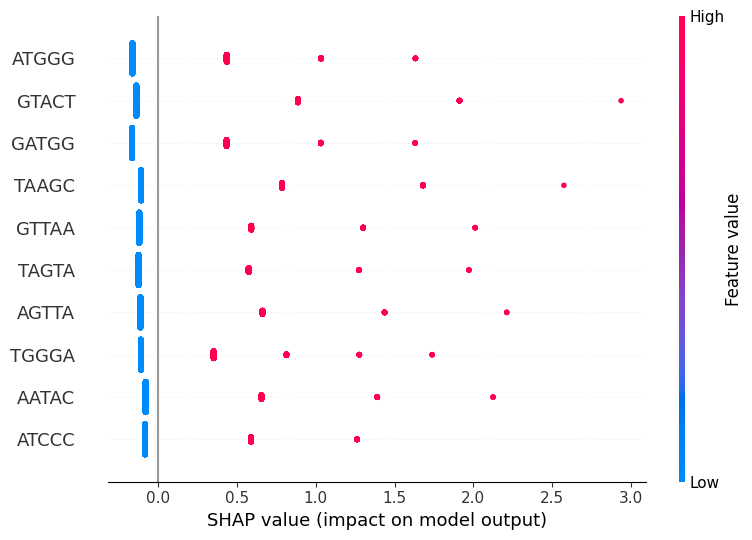


Classe: 5_8S_rRNA


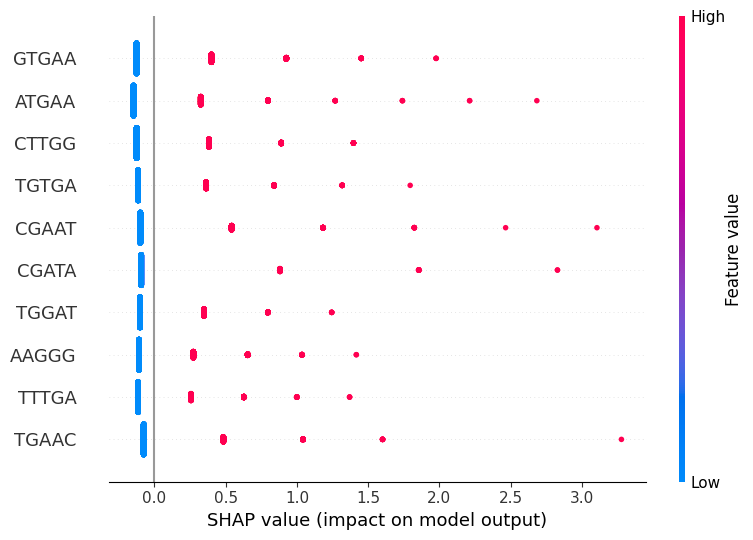


Classe: CD-box


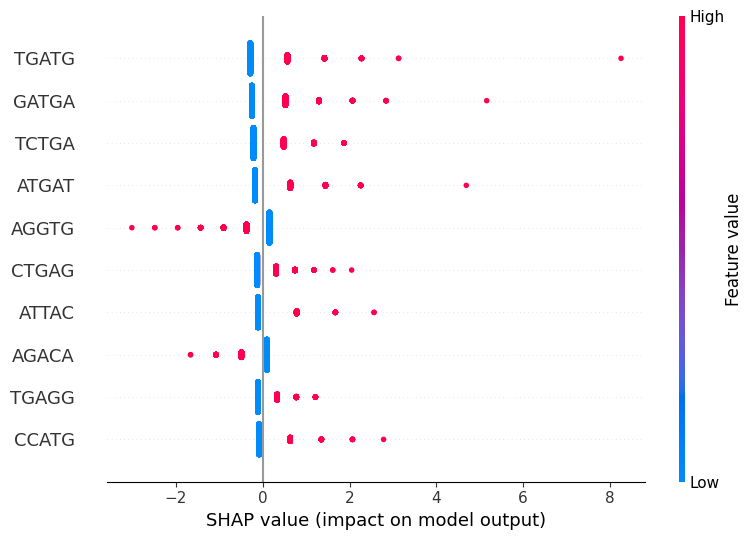


Classe: HACA-box


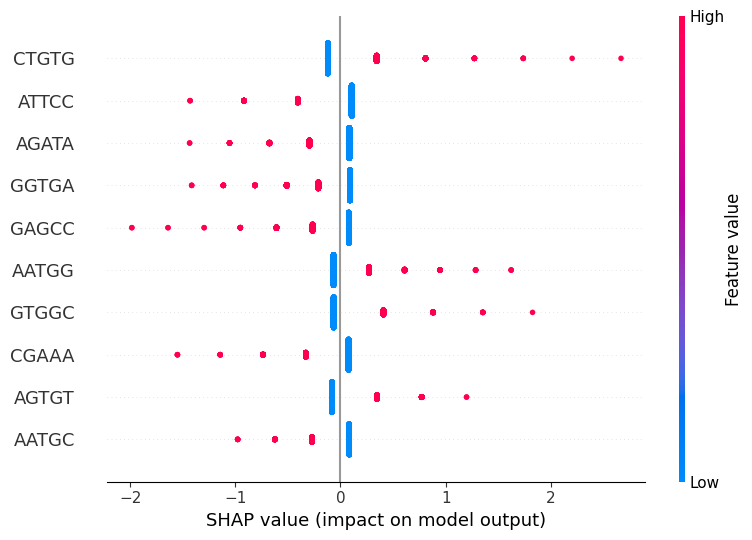


Classe: IRES


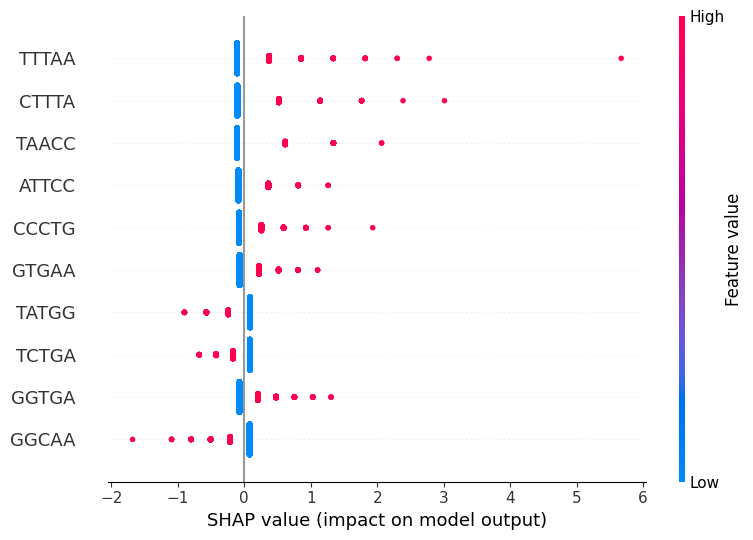


Classe: Intron_gpI


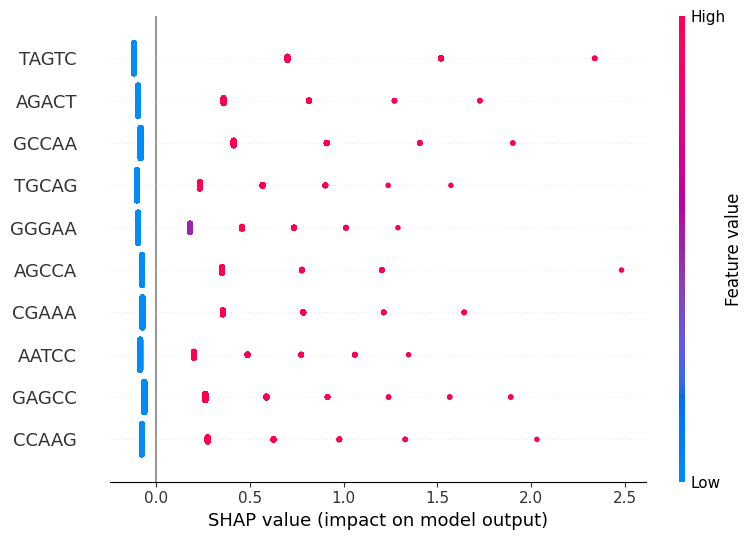


Classe: Intron_gpII


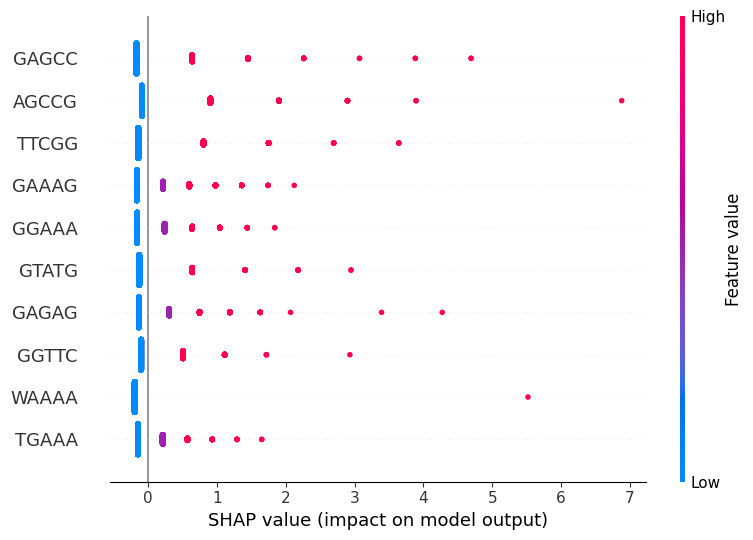


Classe: leader


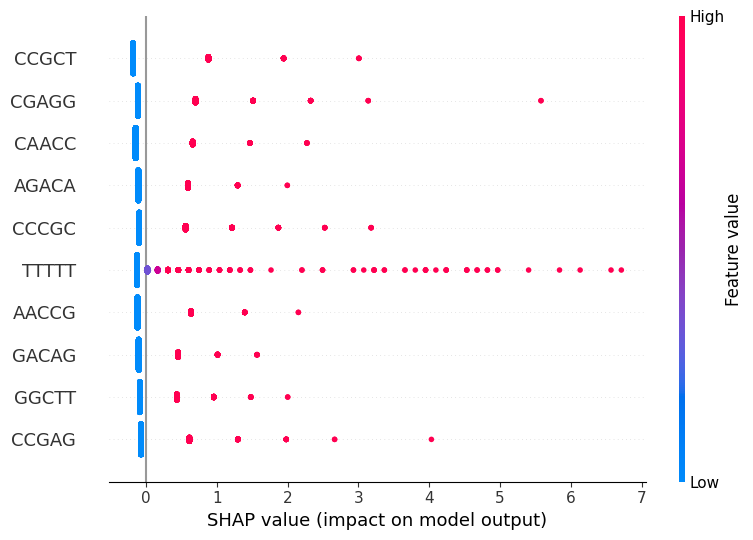


Classe: miRNA


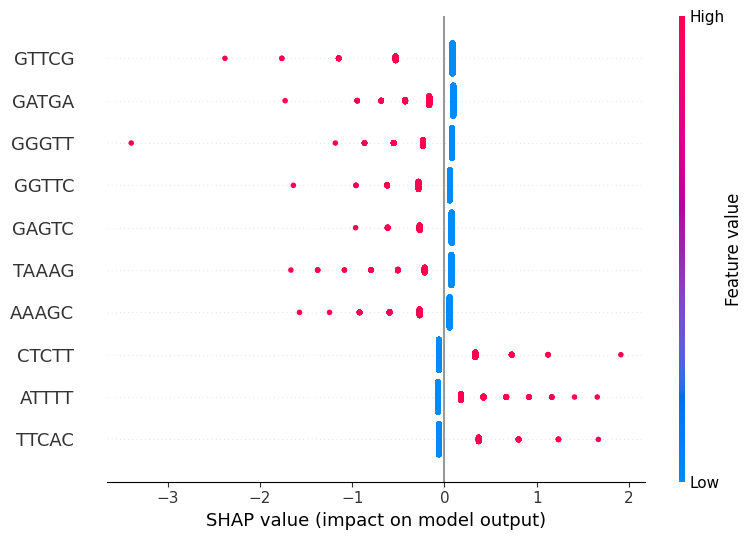


Classe: riboswitch


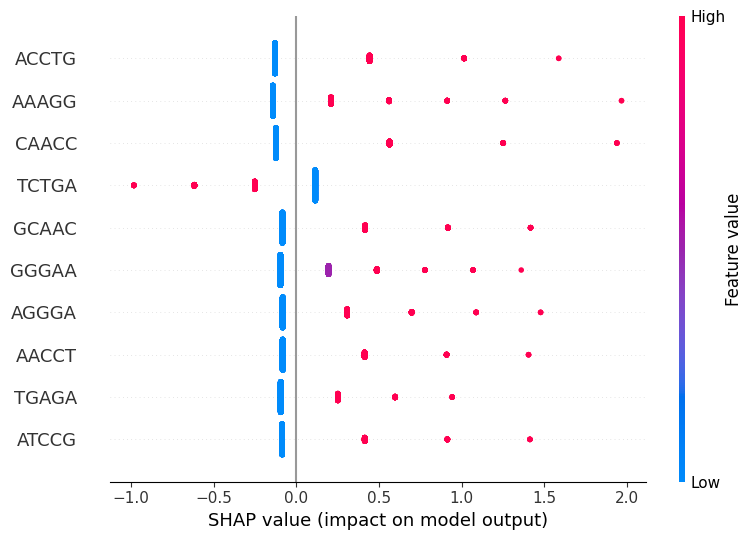


Classe: ribozyme


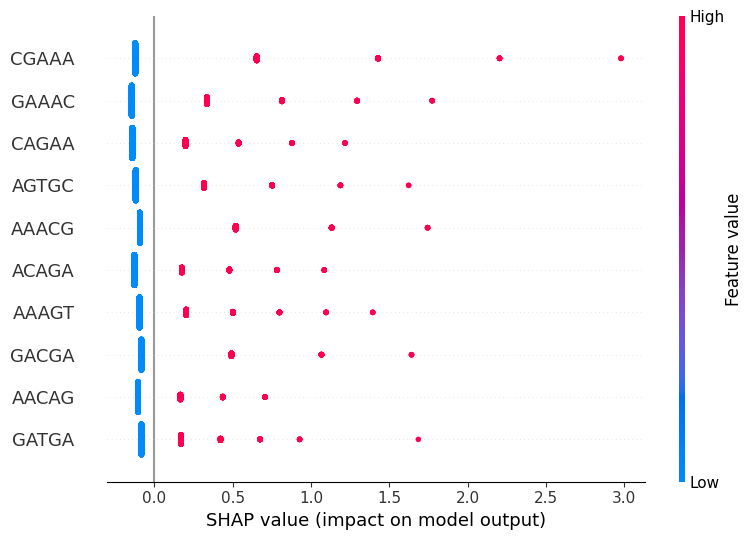


Classe: scaRNA


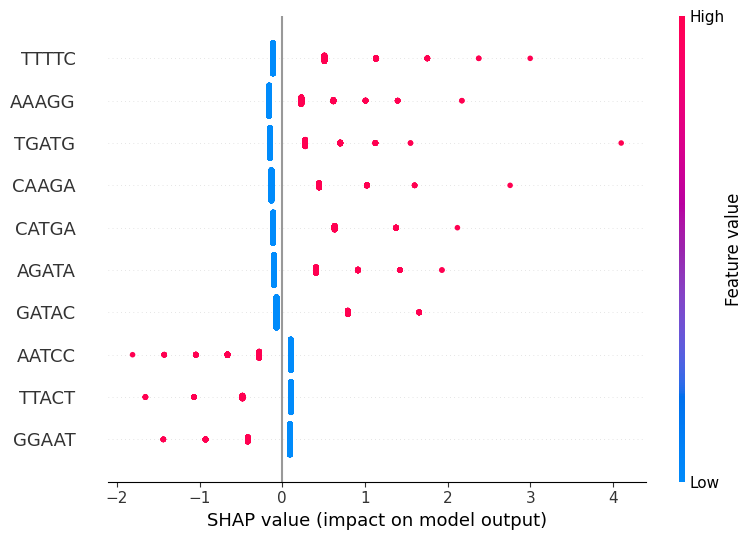


Classe: tRNA


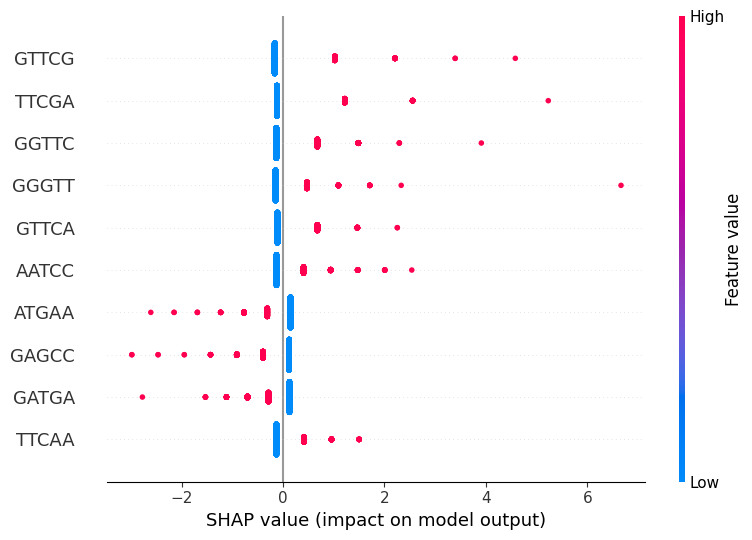

In [68]:
# Extrai os nomes das colunas (features) do DataFrame original, que representam os k-mers
feature_names = data.columns.tolist()
class_names = label_encoder.classes_

# Loop para gerar um gráfico SHAP para cada uma das 13 classes
for i, class_name in enumerate(class_names):  # Para cada classe no modelo multi-classe
    # Gera o gráfico de resumo (summary plot) para a classe `i`
    # shap_values[:, :, i] seleciona os SHAP values da classe i para todas as amostras e todas as features
    # X_train são os dados de entrada usados para calcular os shap_values
    # feature_names define os nomes das barras no gráfico (nomes dos k-mers)
    # max_display=10 limita o número de atributos mostrados aos 10 mais importantes
    print(f"\nClasse: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=feature_names, max_display=10)


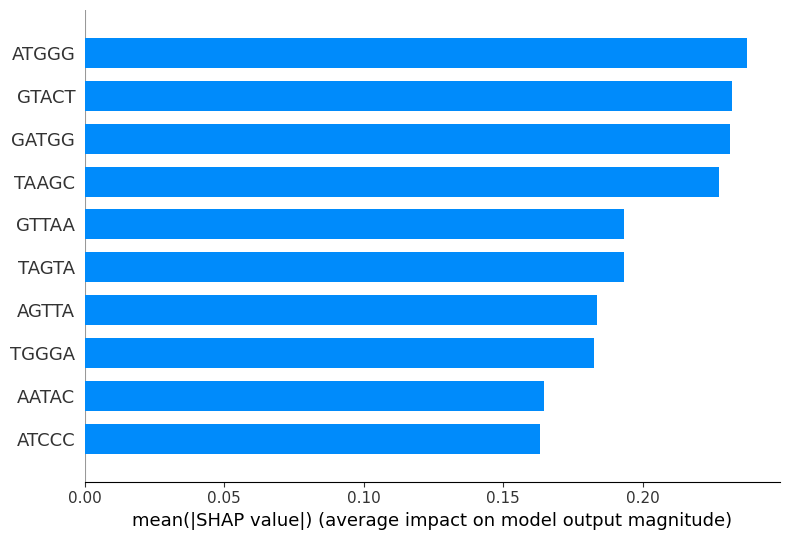

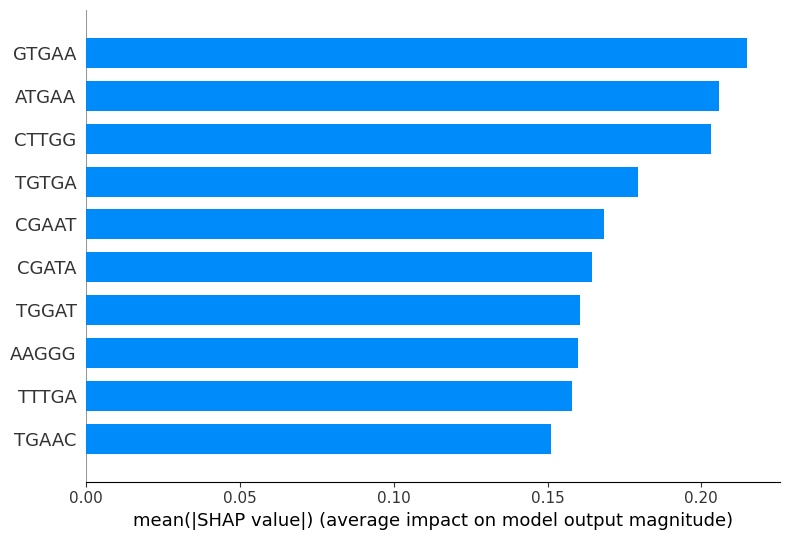

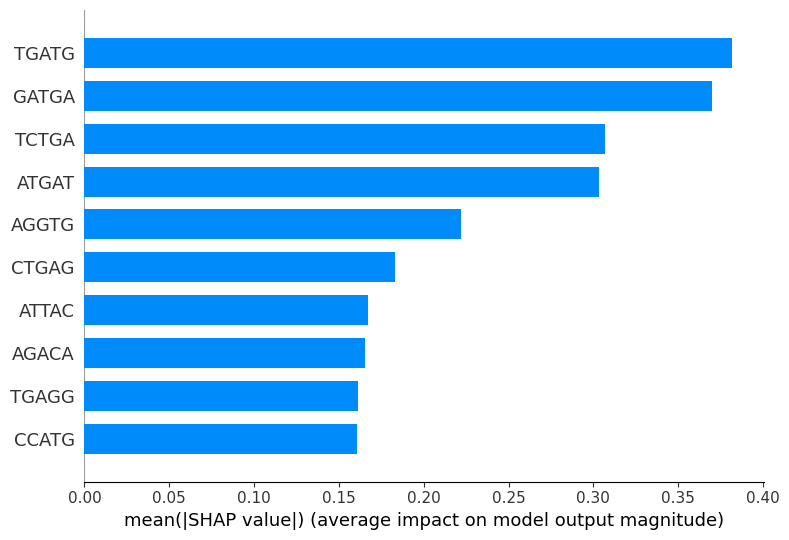

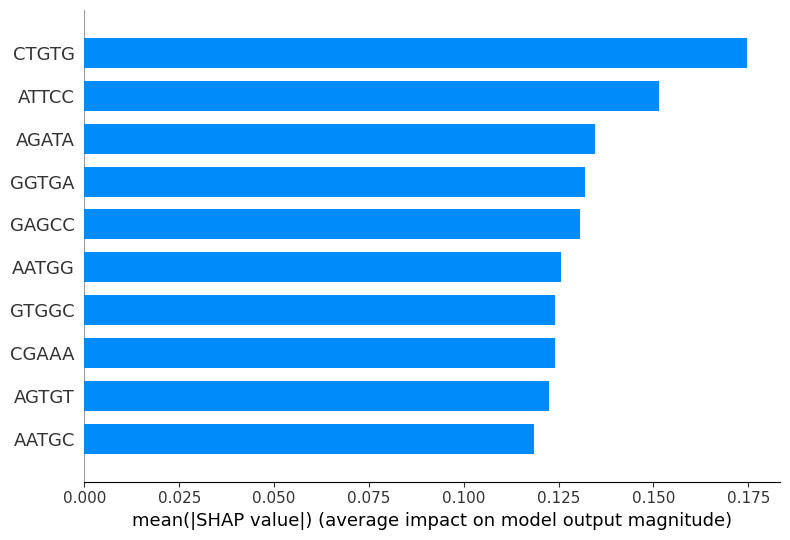

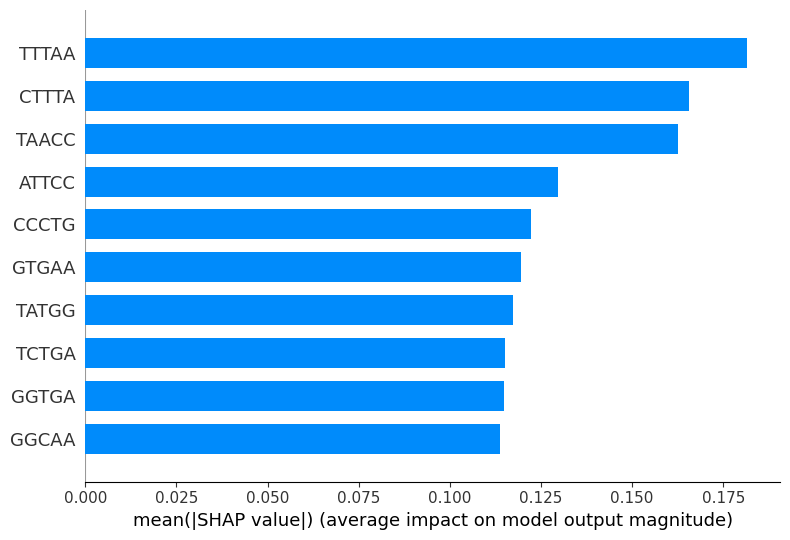

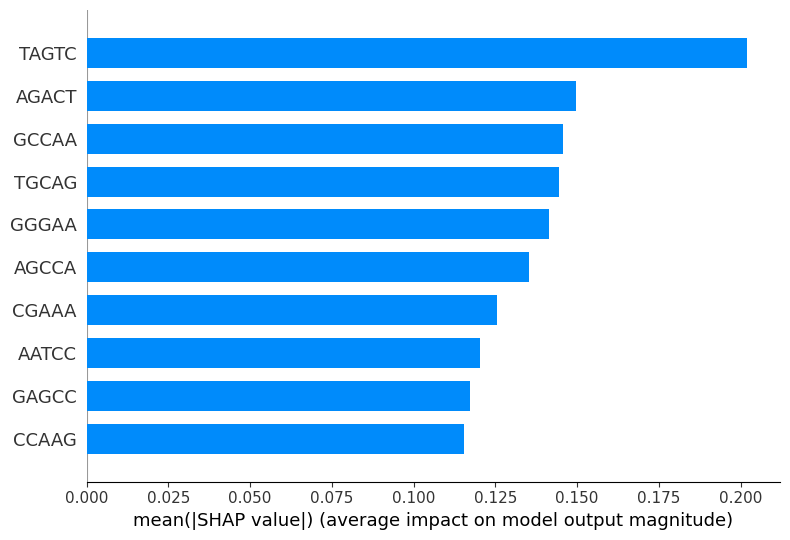

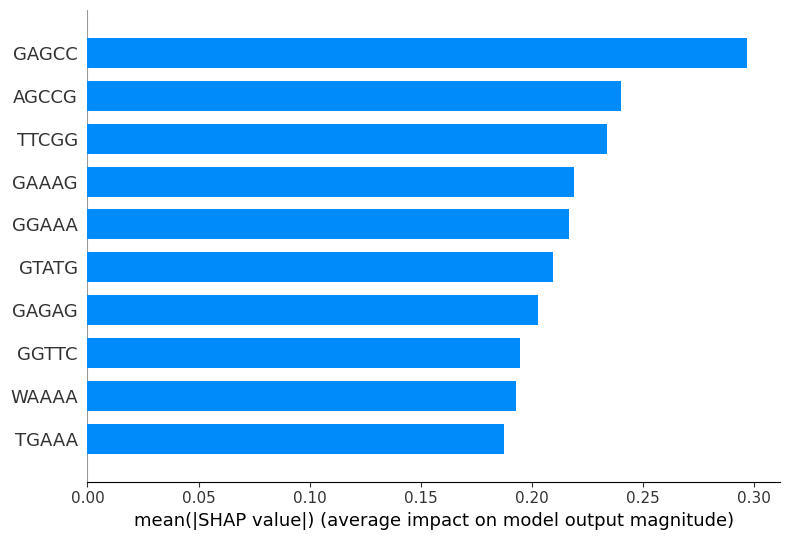

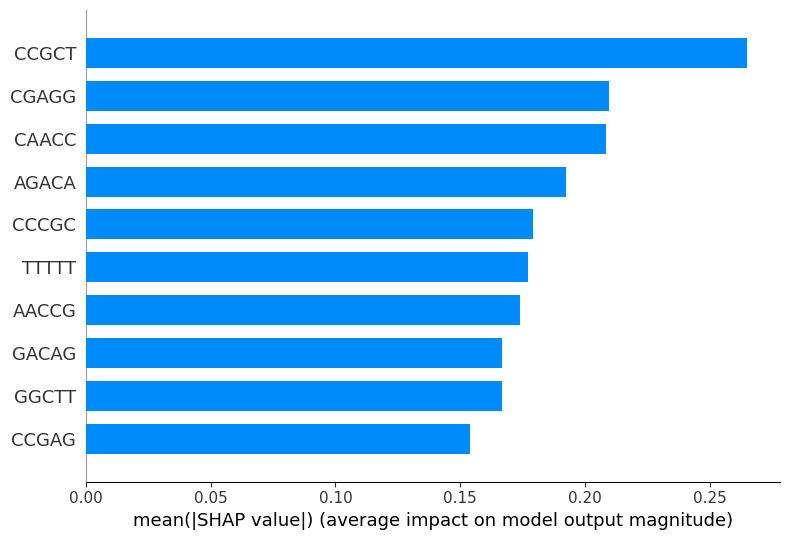

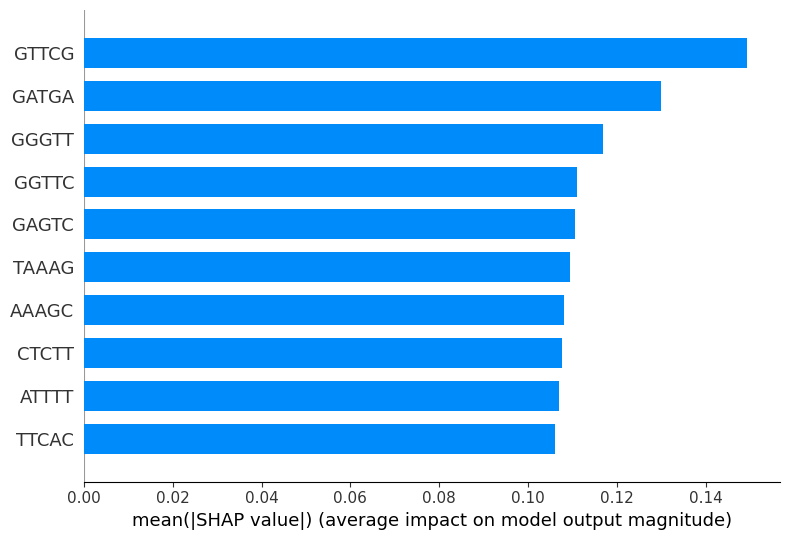

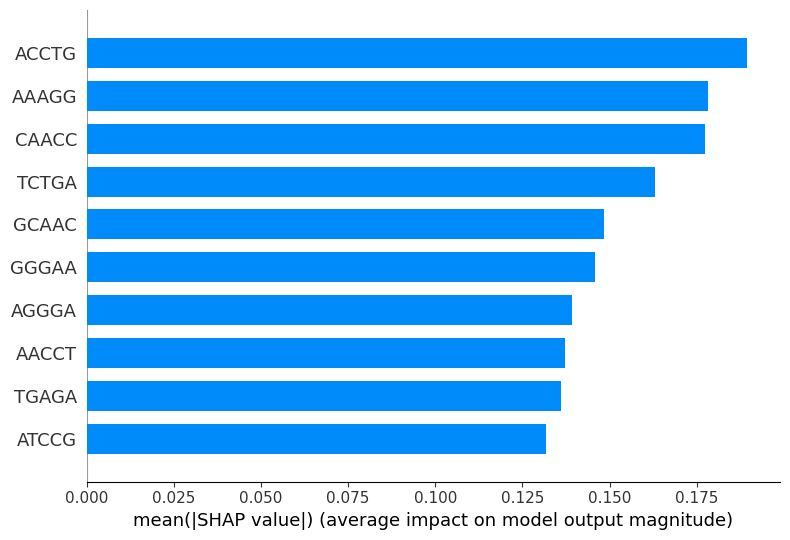

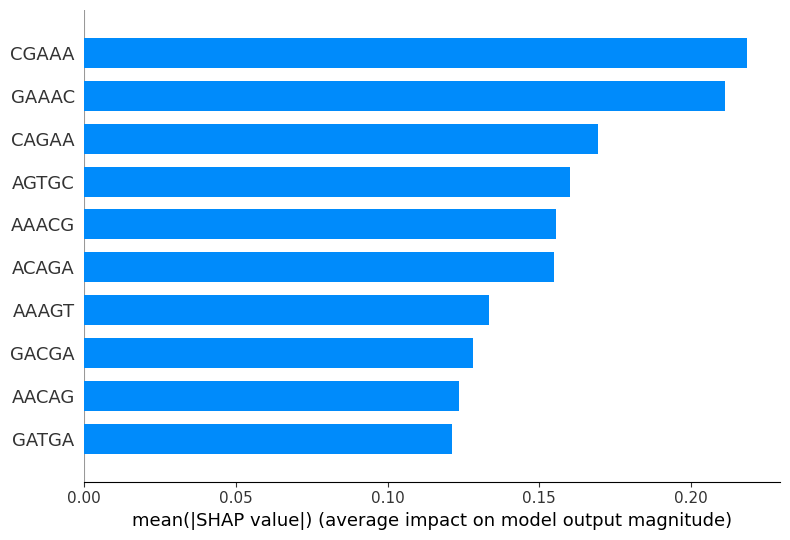

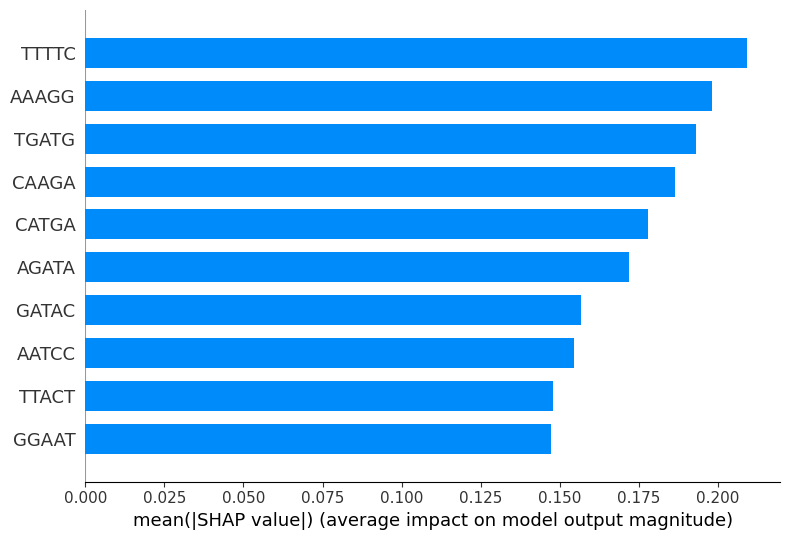

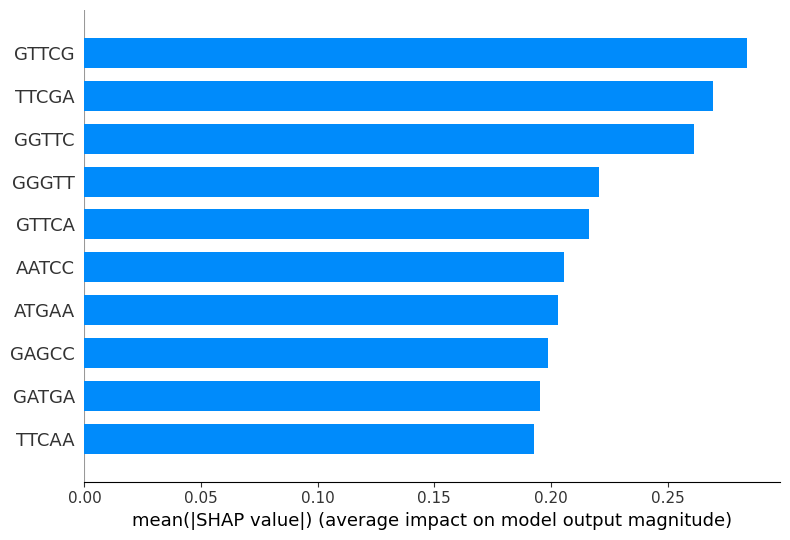

In [69]:
for i, class_name in enumerate(class_names):
    shap.summary_plot(shap_values[:, :, i], X_train,
        feature_names=feature_names, plot_type="bar", max_display=10, show=True)

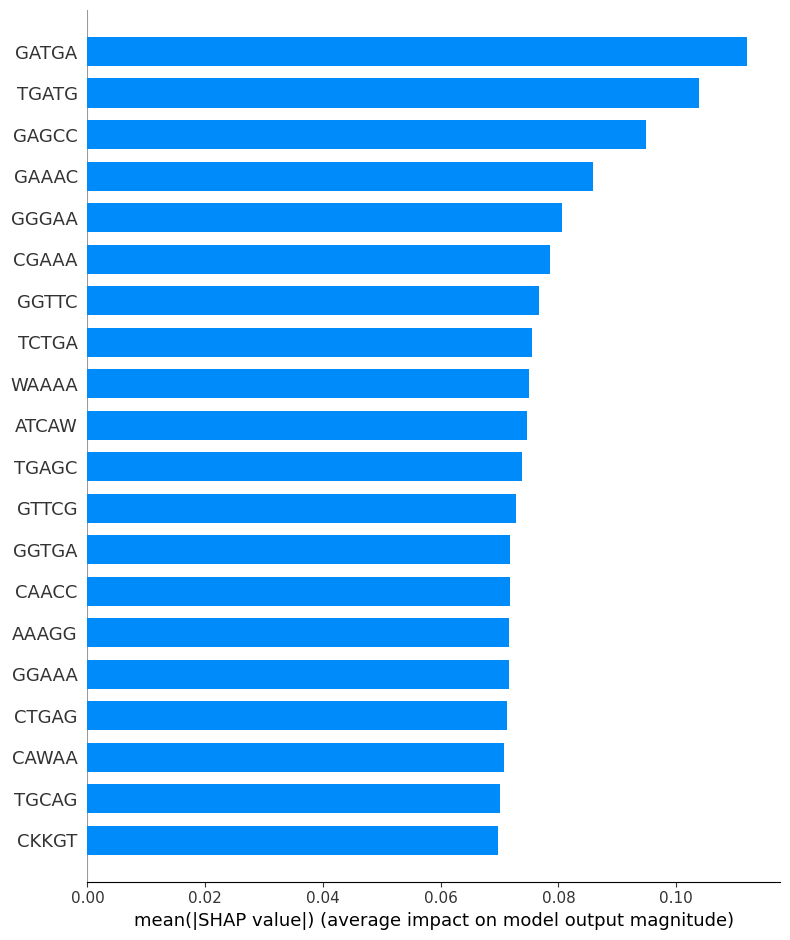

In [70]:
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)  # (features, classes)
global_importance = np.mean(mean_abs_shap, axis=1)  # (features,)

shap.summary_plot(
    global_importance.reshape(1, -1),
    X_train[:1],
    feature_names=feature_names,
    plot_type="bar"
)


Classe: 5S_rRNA


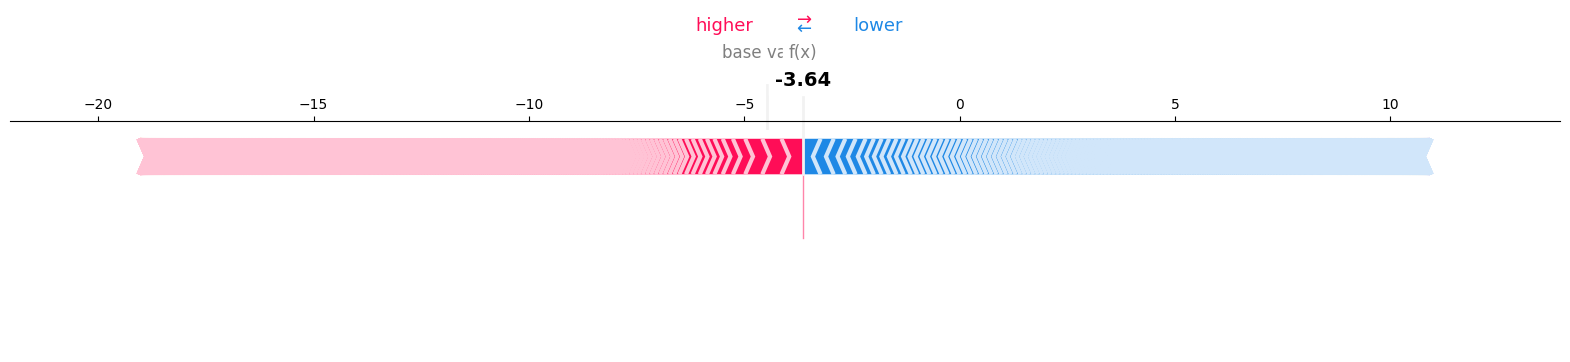


Classe: 5_8S_rRNA


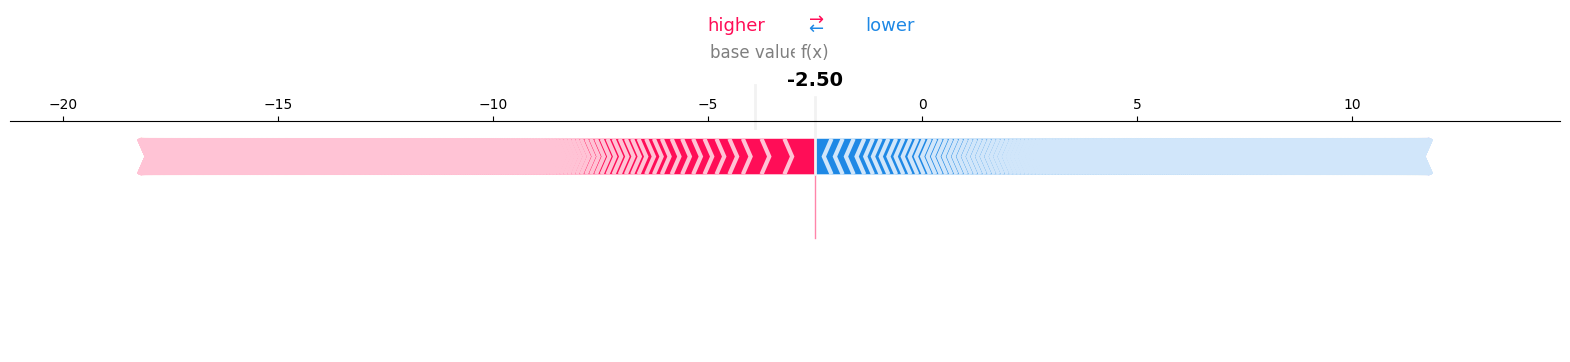


Classe: CD-box


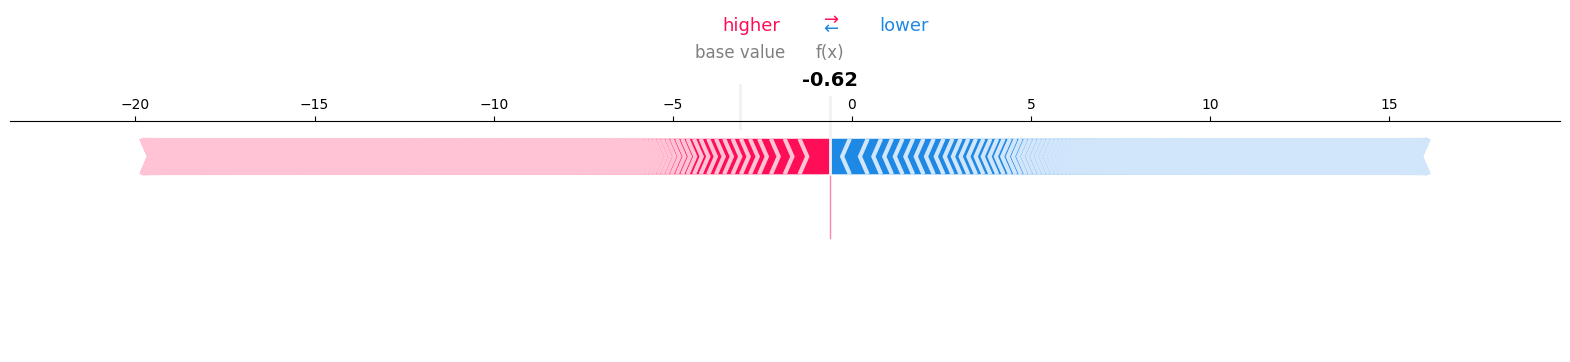


Classe: HACA-box


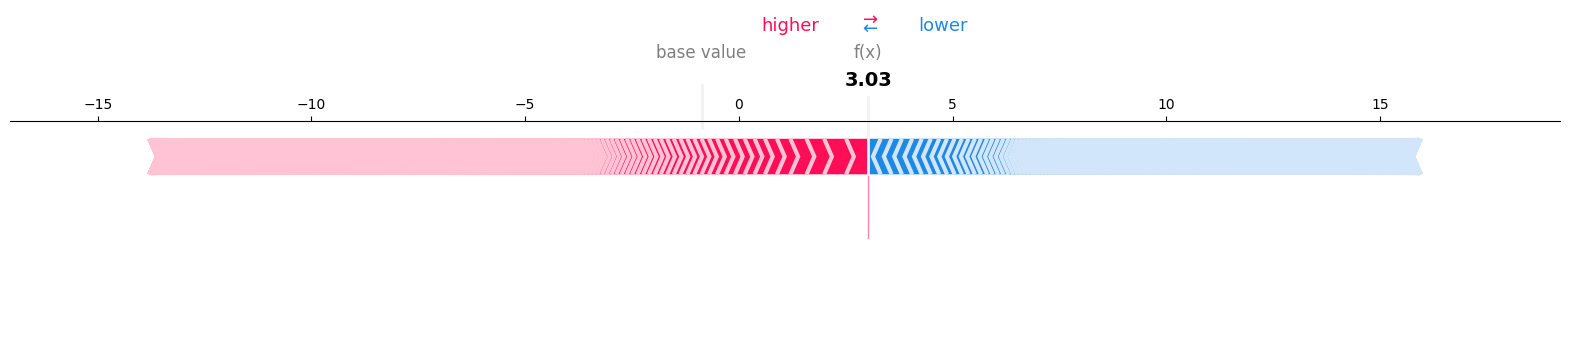


Classe: IRES


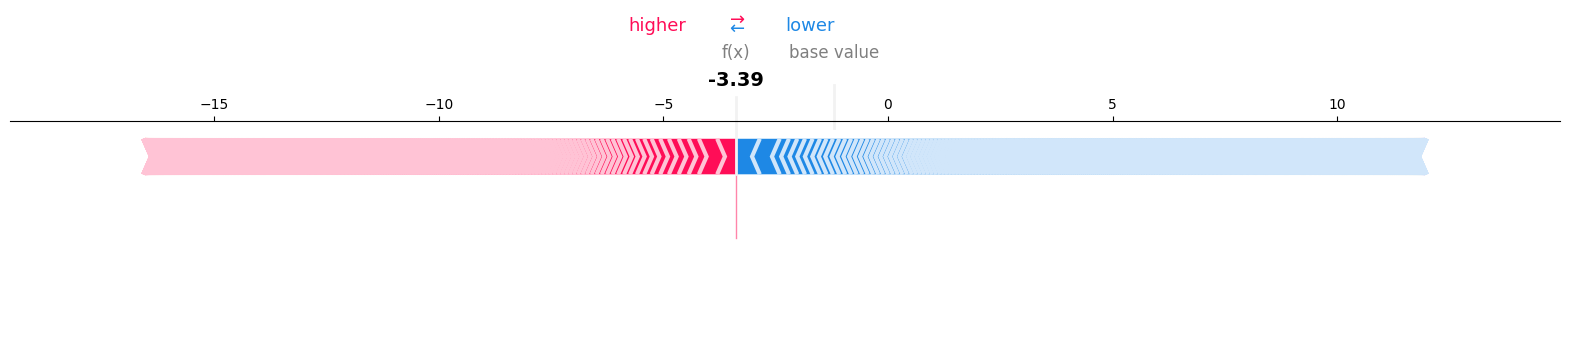


Classe: Intron_gpI


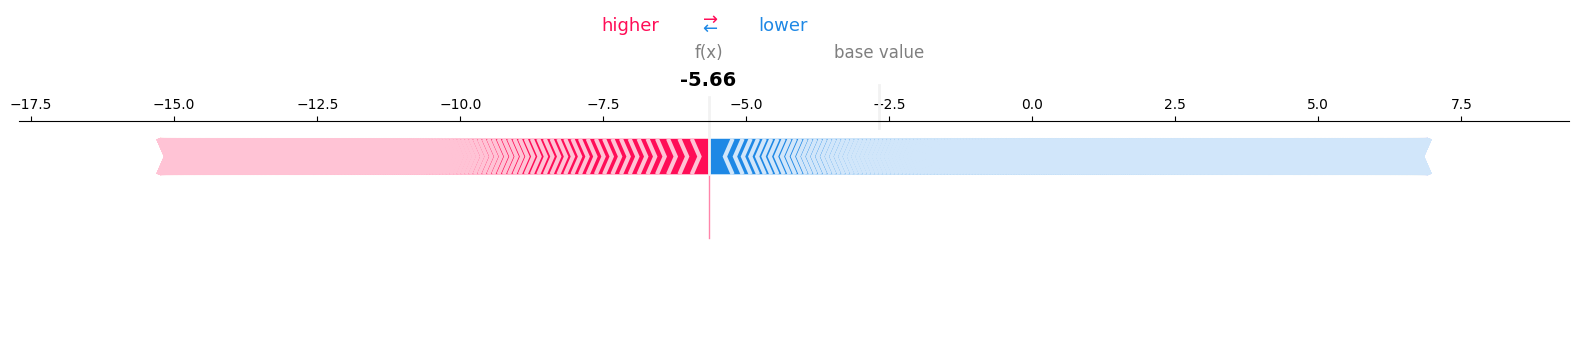


Classe: Intron_gpII


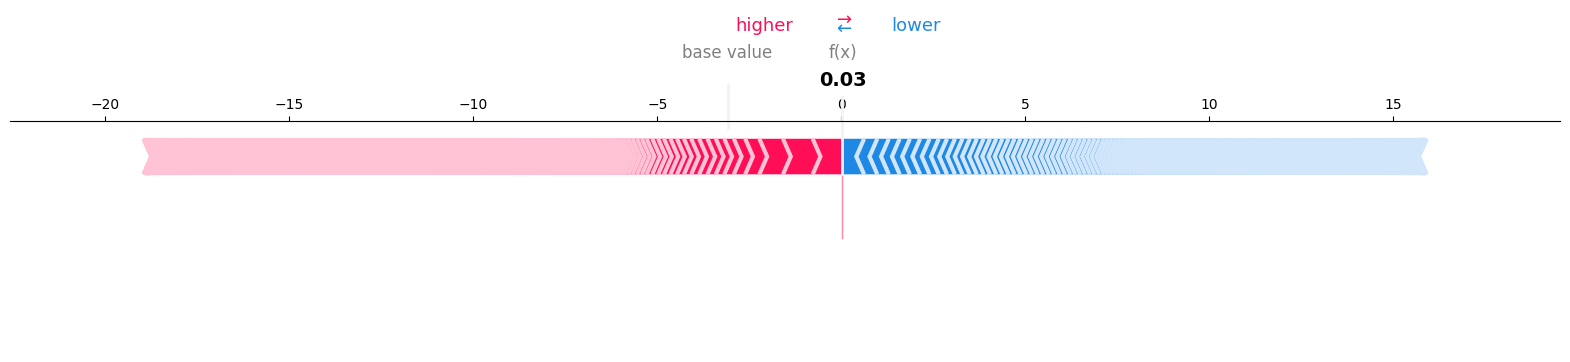


Classe: leader


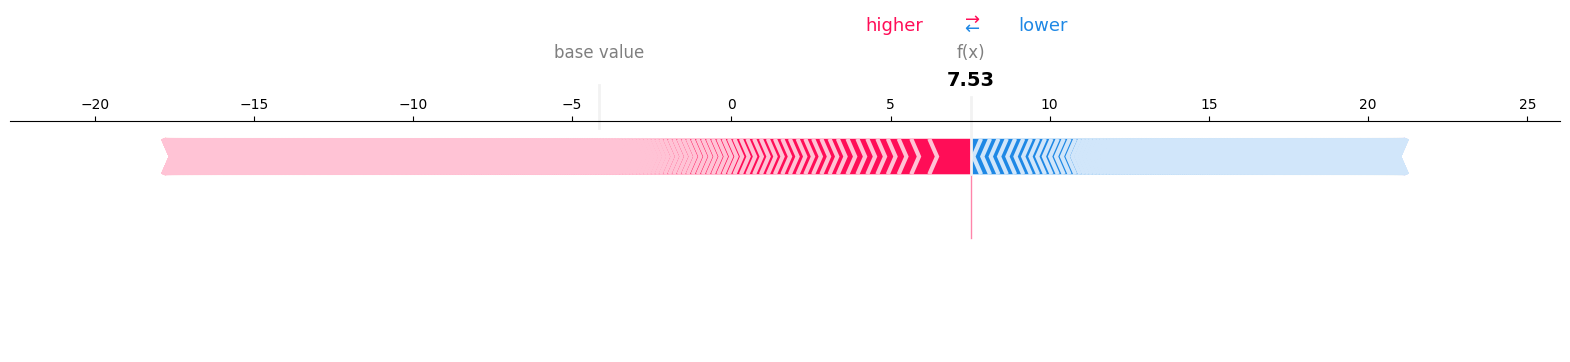


Classe: miRNA


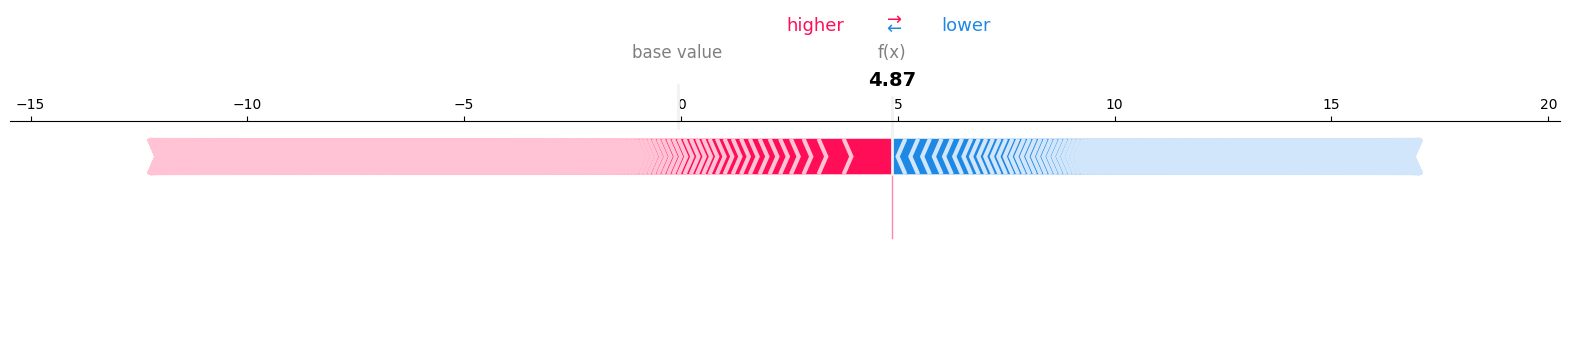


Classe: riboswitch


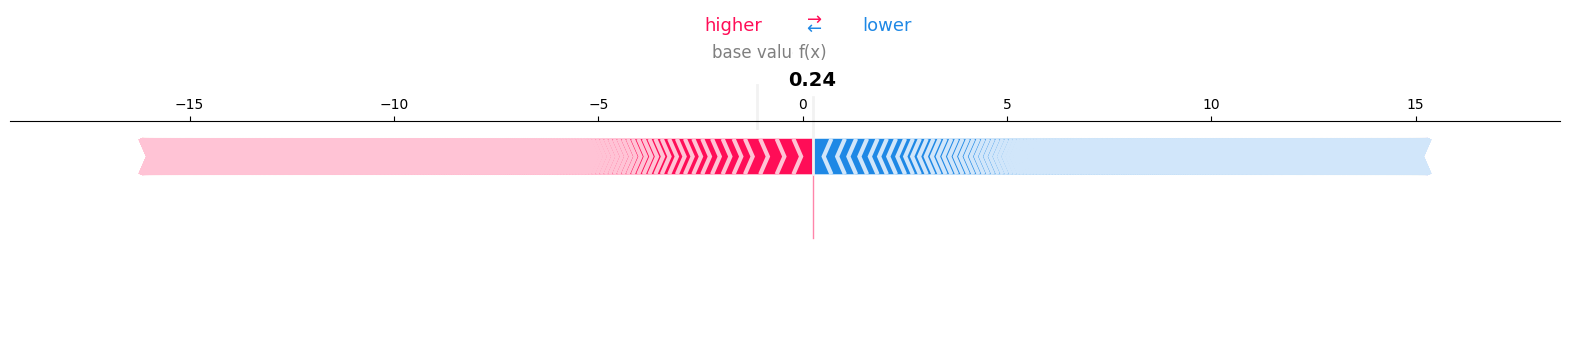


Classe: ribozyme


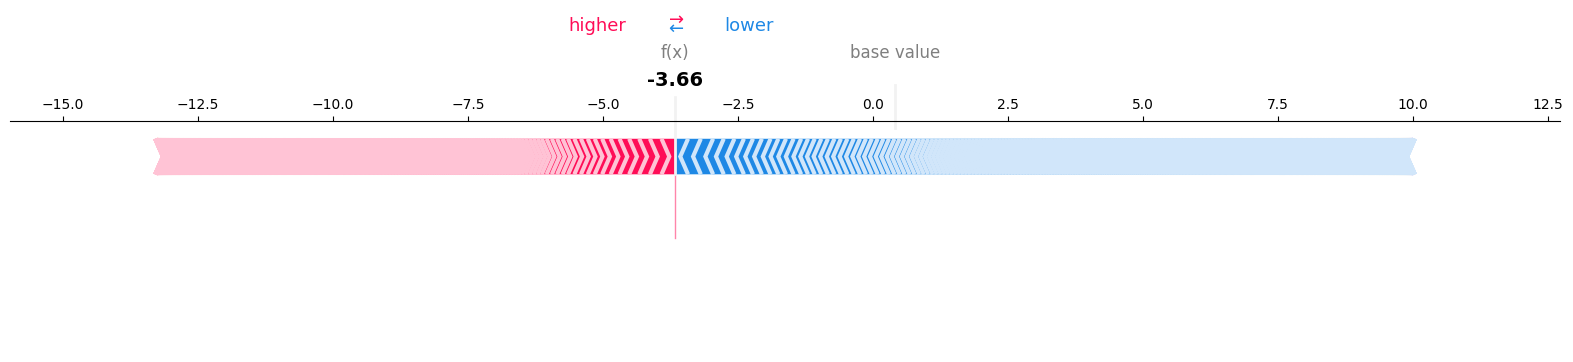


Classe: scaRNA


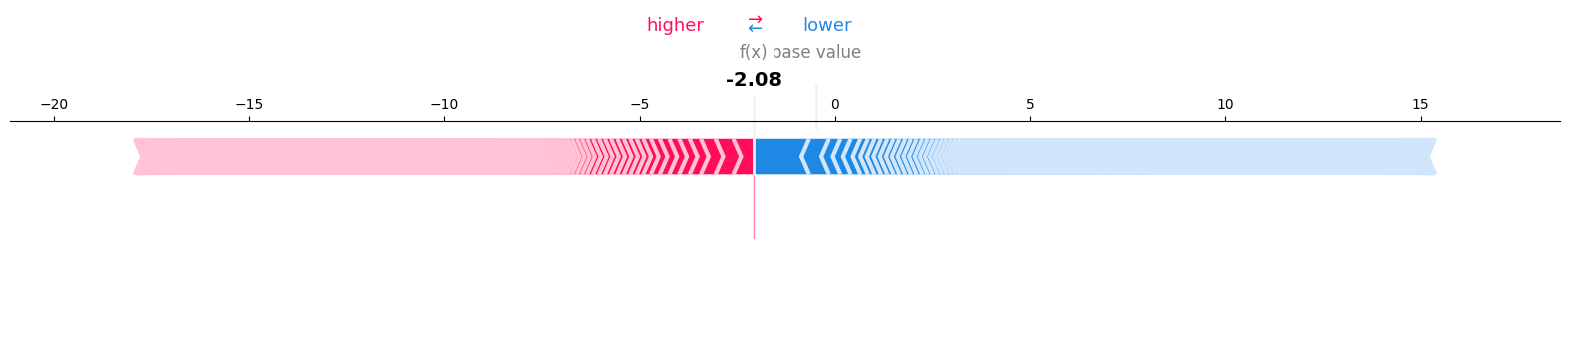


Classe: tRNA


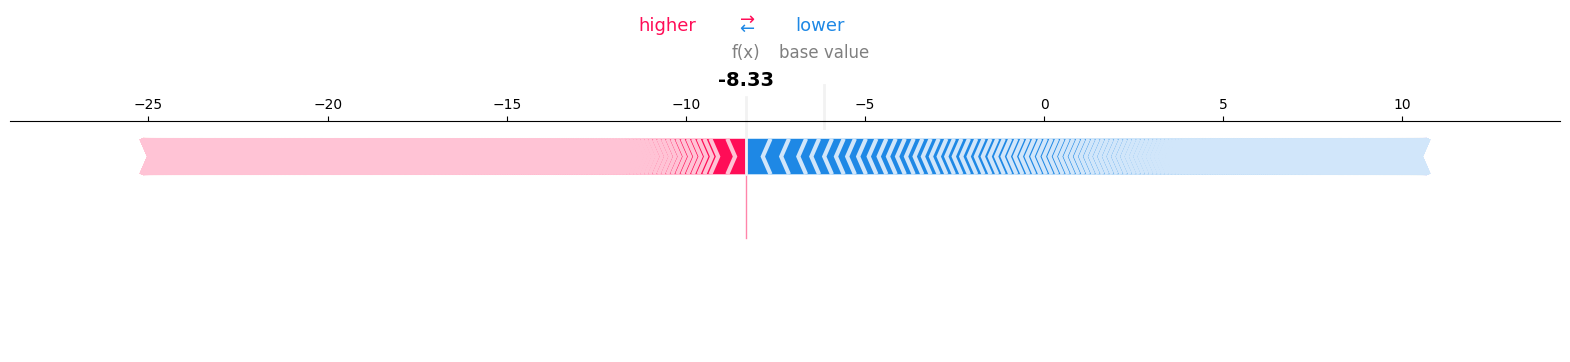

In [71]:
i = 0  # amostra

for c, class_name in enumerate(class_names):
    print(f"\nClasse: {class_name}")

    shap.force_plot(
        explainer.expected_value[c],
        shap_values[i, :, c],
        X_train[i],
        feature_names=feature_names,
        matplotlib=True
    )

Parece haver uma limitação ou no modelo ou nos dados. Vamos então tentar utilizar um modelo mais complexo e que consiga capturar padrões mais complexos e que um mlp não consegue.